Using device: cuda
Dataset path: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000
Classes   : {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Total rows: 10015
Train: 8012 | Test: 2003
Pre-loading TRAIN images...


100%|██████████| 8012/8012 [02:33<00:00, 52.16it/s]


Pre-loading TEST images...


100%|██████████| 2003/2003 [00:35<00:00, 56.53it/s]


Pre-load complete.
Val: 1602 | Test: 2003

✅ Disjoint partitions verified.
Client sizes: [1352, 1482, 5178]
  Client 0: [209, 328, 88, 10, 89, 537, 91]
  Client 1: [27, 42, 703, 73, 89, 536, 12]
  Client 2: [26, 41, 88, 9, 712, 4291, 11]

MAIN TRAINING — frac=0.8, rounds=20

RUNNING FEDAVG
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]


  Round 1/20 fedavg → val F1: 0.5108
  Round 2/20 fedavg → val F1: 0.5743
  Round 3/20 fedavg → val F1: 0.6547
  Round 4/20 fedavg → val F1: 0.6842
  Round 5/20 fedavg → val F1: 0.7089
  Round 6/20 fedavg → val F1: 0.7253
  Round 7/20 fedavg → val F1: 0.7185
  Round 8/20 fedavg → val F1: 0.6981
  Round 9/20 fedavg → val F1: 0.7552
  Round 10/20 fedavg → val F1: 0.7314
  Round 11/20 fedavg → val F1: 0.7702
  Round 12/20 fedavg → val F1: 0.8013
  Round 13/20 fedavg → val F1: 0.7669
  Round 14/20 fedavg → val F1: 0.7774
  Round 15/20 fedavg → val F1: 0.8159
  Round 16/20 fedavg → val F1: 0.7517
  Round 17/20 fedavg → val F1: 0.7770
  Round 18/20 fedavg → val F1: 0.8257
  Round 19/20 fedavg → val F1: 0.8440
  Round 20/20 fedavg → val F1: 0.8122
✅ fedavg → Acc=0.7898  F1=0.6111  ECE=0.1473

RUNNING WEIGHTED_FEDAVG
  Round 1/20 weighted_fedavg → val F1: 0.3607
  Round 2/20 weighted_fedavg → val F1: 0.4485
  Round 3/20 weighted_fedavg → val F1: 0.4464
  Round 4/20 weighted_fedavg → val F1: 0.

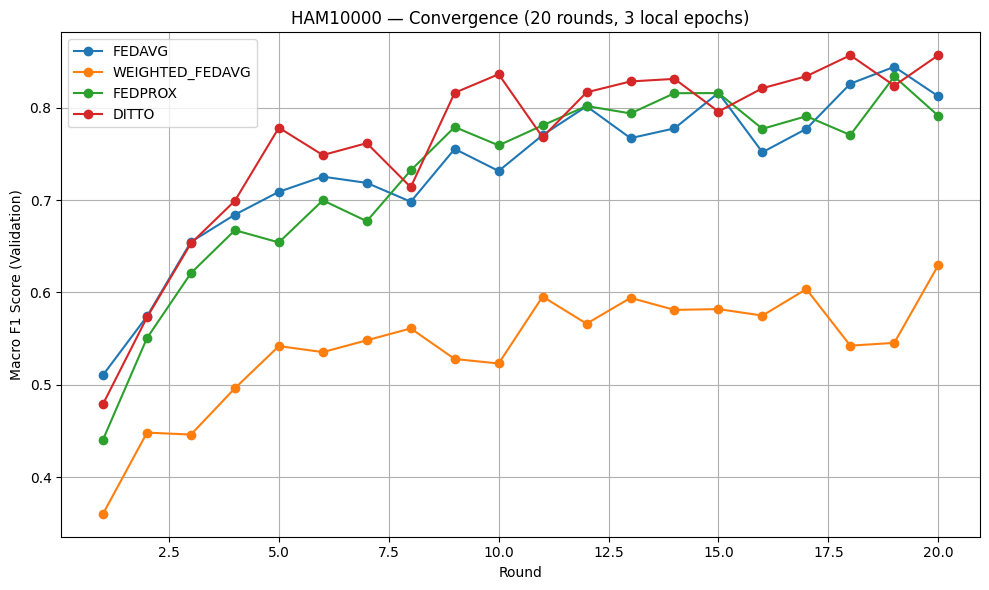

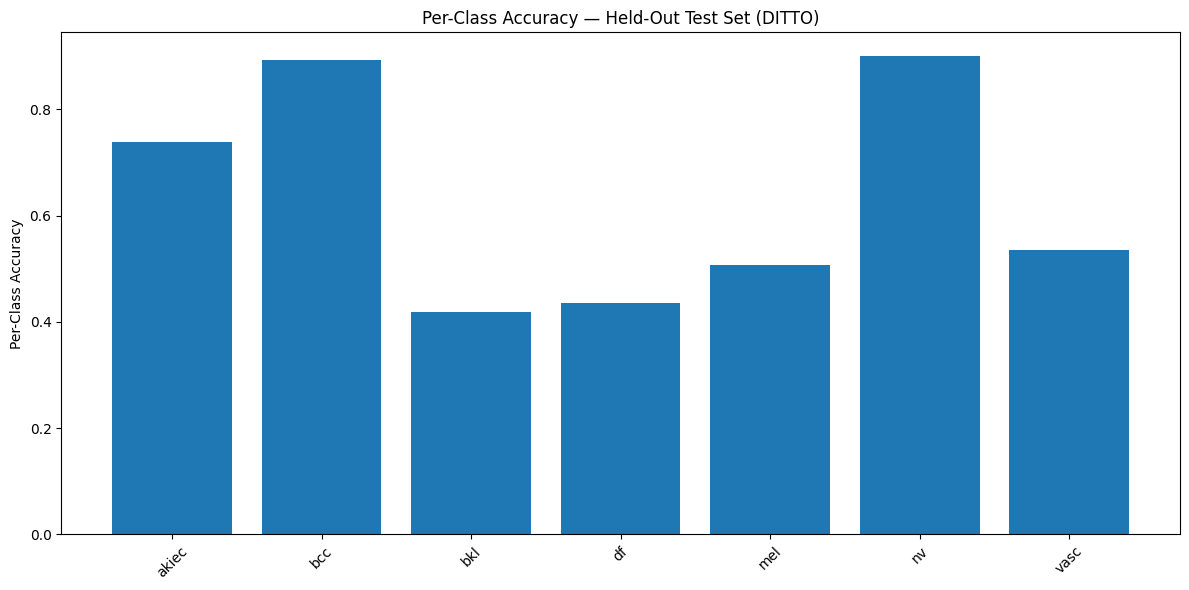


✅ Training complete.
Checkpoint rounds saved: [1, 5, 10, 15, 20]
Files saved:
  fl_results_all_methods.csv, ablation_results.csv
  test_df.csv, train_df.csv, meta.json
  final_model_*.pth, client_*_*.pth
  ckpt_{method}_round{r}.pth  (for CAM evolution)
  client_*_train.csv, client_*_test_split.csv
  convergence_all_methods.png, per_class_accuracy.png


In [1]:
# ==========================================
# CELL 1: HAM10000 FL TRAINING
# Methods: FedAvg, Weighted FedAvg, FedProx, Ditto
# Includes: Main training (20 rounds) + Ablation
# Saves: All models + intermediate round checkpoints
#        for CAM evolution in Cell 2
# ==========================================

!pip install -q kagglehub scikit-learn torchmetrics tqdm

import os, copy, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, balanced_accuracy_score
)
import matplotlib.pyplot as plt
from PIL import Image
from collections import OrderedDict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. DATASET DOWNLOAD
# ==========================================
import kagglehub
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print(f"Dataset path: {path}")

df   = pd.read_csv(os.path.join(path, "HAM10000_metadata.csv"))
img1 = os.path.join(path, "HAM10000_images_part_1")
img2 = os.path.join(path, "HAM10000_images_part_2")

label_map   = {l: i for i, l in enumerate(sorted(df['dx'].unique()))}
df['label'] = df['dx'].map(label_map)
num_classes = len(label_map)
class_names = list(label_map.keys())
print(f"Classes   : {label_map}")
print(f"Total rows: {len(df)}")

# ==========================================
# 2. TRAIN / TEST SPLIT
# ==========================================
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=42)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"Train: {len(train_df)} | Test: {len(test_df)}")

# ==========================================
# 3. PRE-LOAD IMAGES INTO RAM
# ==========================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

def load_image(img_id):
    p1 = os.path.join(img1, img_id + ".jpg")
    p2 = os.path.join(img2, img_id + ".jpg")
    try:
        return transform(
            Image.open(p1 if os.path.exists(p1) else p2).convert("RGB"))
    except Exception:
        return torch.zeros(3, 224, 224)

print("Pre-loading TRAIN images...")
train_tensors = [load_image(r['image_id'])
                 for _, r in tqdm(train_df.iterrows(),
                                  total=len(train_df))]
train_labels  = train_df['label'].tolist()

print("Pre-loading TEST images...")
test_tensors = [load_image(r['image_id'])
                for _, r in tqdm(test_df.iterrows(),
                                 total=len(test_df))]
test_labels  = test_df['label'].tolist()
print("Pre-load complete.")

# ==========================================
# 4. DATASET CLASS
# ==========================================
class InMemoryDataset(Dataset):
    def __init__(self, images, labels, noise_level=0.0):
        self.images      = images
        self.labels      = labels
        self.noise_level = noise_level

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx].clone()
        if self.noise_level > 0:
            img += torch.randn_like(img) * self.noise_level / 255.0
            img  = torch.clamp(img, 0, 1)
        return img, self.labels[idx]

test_dataset = InMemoryDataset(test_tensors, test_labels)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)

val_idx    = np.random.RandomState(42).choice(
                 len(train_tensors), int(0.2 * len(train_tensors)),
                 replace=False)
val_imgs   = [train_tensors[i] for i in val_idx]
val_lbls   = [train_labels[i]  for i in val_idx]
val_loader = DataLoader(InMemoryDataset(val_imgs, val_lbls),
                        batch_size=32, shuffle=False,
                        num_workers=2, pin_memory=True)
print(f"Val: {len(val_idx)} | Test: {len(test_dataset)}")

# ==========================================
# 5. DISJOINT NON-IID SPLIT
# ==========================================
majority_classes_per_client = [[0, 1], [2, 3], [4, 5]]

def disjoint_non_iid_split(labels, majority_per_client,
                            majority_frac=0.8, seed=42):
    np.random.seed(seed)
    labels_arr = np.array(labels)
    n_clients  = len(majority_per_client)
    assigned   = np.full(len(labels), -1, dtype=int)

    for class_id in range(num_classes):
        pos = np.where(labels_arr == class_id)[0].tolist()
        np.random.shuffle(pos)
        owner = next(
            (c for c, g in enumerate(majority_per_client)
             if class_id in g), 0)
        n_maj   = int(len(pos) * majority_frac)
        maj_pos = pos[:n_maj]
        oth_pos = pos[n_maj:]
        for i in maj_pos: assigned[i] = owner
        others = [c for c in range(n_clients) if c != owner]
        for c, chunk in zip(others,
                np.array_split(oth_pos, max(len(others), 1))):
            for i in chunk: assigned[i] = c

    assigned[assigned == -1] = 0

    for ci in range(n_clients):
        for cj in range(ci + 1, n_clients):
            pi = set(np.where(assigned == ci)[0])
            pj = set(np.where(assigned == cj)[0])
            assert pi.isdisjoint(pj), \
                f"Overlap between client {ci} and {cj}!"

    return [np.where(assigned == c)[0].tolist()
            for c in range(n_clients)]

MAIN_FRAC      = 0.8
client_indices = disjoint_non_iid_split(
    train_labels, majority_classes_per_client,
    majority_frac=MAIN_FRAC)
client_sizes   = [len(idx) for idx in client_indices]

print(f"\n✅ Disjoint partitions verified.")
print(f"Client sizes: {client_sizes}")
for i, idx in enumerate(client_indices):
    cl = [train_labels[j] for j in idx]
    print(f"  Client {i}: "
          f"{np.bincount(cl, minlength=num_classes).tolist()}")

# ==========================================
# 6. DATALOADERS
# ==========================================
class_counts     = np.bincount(train_labels, minlength=num_classes)
class_weights_t  = torch.tensor(
    1.0/class_counts / (1.0/class_counts).sum(),
    dtype=torch.float32).to(device)

NOISE_LEVELS = [0.0, 20.0, 10.0]

def get_dataloader(indices, noise_level=0.0, batch_size=32):
    imgs    = [train_tensors[i] for i in indices]
    lbls    = [train_labels[i]  for i in indices]
    ds      = InMemoryDataset(imgs, lbls, noise_level)
    counts  = np.bincount(lbls, minlength=num_classes)
    sw      = 1.0 / counts[lbls]; sw /= sw.sum()
    sampler = WeightedRandomSampler(sw, len(sw), replacement=True)
    return DataLoader(ds, batch_size=batch_size, sampler=sampler,
                      num_workers=2, pin_memory=True)

dataloaders = [
    get_dataloader(client_indices[i], noise_level=NOISE_LEVELS[i])
    for i in range(3)
]

# ==========================================
# 7. MODEL
# ==========================================
def get_model():
    m    = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m.to(device)

# ==========================================
# 8. METRICS
# ==========================================
def compute_ece(y_prob, y_true, n_bins=15):
    try:
        from torchmetrics import CalibrationError
        calib = CalibrationError(task='multiclass',
                                 num_classes=num_classes,
                                 n_bins=n_bins, norm='l1')
        return calib(torch.tensor(y_prob),
                     torch.tensor(y_true)).item()
    except Exception:
        pt=torch.tensor(y_prob); lt=torch.tensor(y_true)
        conf,pred=pt.max(dim=1); acc=pred.eq(lt)
        edges=torch.linspace(0,1,n_bins+1); ece=0.0
        for i in range(n_bins):
            mask=(conf>edges[i])&(conf<=edges[i+1])
            if mask.sum()>0:
                ece+=mask.sum().item()*abs(
                    acc[mask].float().mean().item()-
                    conf[mask].mean().item())
        return ece/max(len(y_true),1)

def compute_all_metrics(y_true, y_pred, y_prob=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    pc_prec, pc_rec, pc_acc = [], [], []
    for c in range(num_classes):
        tp   = np.sum((y_pred==c)&(y_true==c))
        fp   = np.sum((y_pred==c)&(y_true!=c))
        fn   = np.sum((y_pred!=c)&(y_true==c))
        pc_prec.append(tp/(tp+fp) if (tp+fp)>0 else 0.0)
        pc_rec.append( tp/(tp+fn) if (tp+fn)>0 else 0.0)
        pc_acc.append( np.mean(y_pred[y_true==c]==c)
                       if np.sum(y_true==c)>0 else 0.0)
    return {
        'accuracy':            accuracy_score(y_true, y_pred),
        'balanced_accuracy':   balanced_accuracy_score(y_true, y_pred),
        'f1_macro':            f1_score(y_true,y_pred,average='macro',
                                        zero_division=0),
        'f1_weighted':         f1_score(y_true,y_pred,average='weighted',
                                        zero_division=0),
        'precision_macro':     precision_score(y_true,y_pred,
                                               average='macro',
                                               zero_division=0),
        'recall_macro':        recall_score(y_true,y_pred,
                                            average='macro',
                                            zero_division=0),
        'per_class_precision': pc_prec,
        'per_class_recall':    pc_rec,
        'per_class_accuracy':  pc_acc,
        'g_mean': np.exp(np.mean(np.log(
                         [r+1e-8 for r in pc_rec]))),
        'ece':    compute_ece(y_prob, y_true.tolist())
                  if y_prob is not None else None,
        'y_true': y_true.tolist(),
        'y_pred': y_pred.tolist(),
    }

def evaluate_model(model, dataloader, return_probs=False):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for x, y in dataloader:
            x     = x.to(device)
            probs = F.softmax(model(x), dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())
            all_probs.extend(probs.cpu().numpy())
    return compute_all_metrics(
        all_labels, all_preds,
        all_probs if return_probs else None)

# ==========================================
# 9. LOCAL TRAINING
# ==========================================
MU = 0.001

def train_local(model, loader, global_state_dict,
                local_epochs=3, lr=1e-4,
                mu=0.0, ditto_lambda=0.0):
    model.train()
    optimizer = optim.AdamW(model.parameters(),
                            lr=lr, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)

    for _ in range(local_epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            if mu > 0:
                loss += (mu/2) * sum(
                    torch.sum((p-global_state_dict[n].to(device))**2)
                    for n, p in model.named_parameters()
                    if n in global_state_dict
                    and p.dtype.is_floating_point)
            if ditto_lambda > 0:
                loss += ditto_lambda * sum(
                    torch.sum((p-global_state_dict[n].to(device))**2)
                    for n, p in model.named_parameters()
                    if n in global_state_dict
                    and p.dtype.is_floating_point)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0)
            optimizer.step()

    return {k: v.cpu().clone()
            for k, v in model.state_dict().items()}

# ==========================================
# 10. AGGREGATION
# ==========================================
def fedavg_aggregate(local_weights):
    avg = OrderedDict()
    for key in local_weights[0]:
        tensors = [w[key] for w in local_weights]
        avg[key] = torch.stack(tensors).mean(0) \
                   if tensors[0].dtype.is_floating_point \
                   else tensors[0].clone()
    return avg

def weighted_fedavg_aggregate(local_weights, client_sizes):
    total = sum(client_sizes)
    avg   = OrderedDict()
    for key in local_weights[0]:
        tensors = [w[key] for w in local_weights]
        avg[key] = sum(w[key]*(s/total)
                       for w,s in zip(local_weights,client_sizes)) \
                   if tensors[0].dtype.is_floating_point \
                   else tensors[0].clone()
    return avg

def fedprox_aggregate(local_weights, global_weights, mu=MU):
    avg = fedavg_aggregate(local_weights)
    for key in avg:
        if avg[key].dtype.is_floating_point:
            avg[key] = avg[key] - mu*(avg[key]-global_weights[key].cpu())
    return avg

# ==========================================
# 11. GENERIC FL RUNNER
# Saves round checkpoints for CAM evolution
# ==========================================
def run_fl(name, dataloaders, client_sizes,
           rounds=20, local_epochs=3, lr=1e-4,
           save_clients=True,
           checkpoint_rounds=[1, 5, 10, 15, 20]):
    """
    checkpoint_rounds: which rounds to save global model checkpoints
                       for CAM evolution analysis in Cell 2
    """
    gm  = get_model()
    gw  = {k: v.cpu() for k, v in gm.state_dict().items()}
    cms = [get_model() for _ in range(3)]
    pw  = [{k: v.cpu().clone()
            for k, v in gm.state_dict().items()}
           for _ in range(3)]

    best_f1, best_gw = -1.0, None
    history = []

    for rnd in range(rounds):

        if name == 'ditto':
            gl = []
            for cid, loader in enumerate(dataloaders):
                tmp = get_model()
                tmp.load_state_dict(gw, strict=True)
                gl.append(train_local(tmp, loader, gw,
                                      local_epochs=local_epochs,
                                      lr=lr))
            gw = fedavg_aggregate(gl)
            gm.load_state_dict(gw, strict=True)
            for cid, loader in enumerate(dataloaders):
                cms[cid].load_state_dict(pw[cid], strict=True)
                pw[cid] = train_local(cms[cid], loader, gw,
                                      local_epochs=local_epochs,
                                      lr=lr, ditto_lambda=0.005)
        else:
            lw = []
            for cid, loader in enumerate(dataloaders):
                cms[cid].load_state_dict(gw, strict=True)
                lw.append(train_local(
                    cms[cid], loader, gw,
                    local_epochs=local_epochs, lr=lr,
                    mu=(MU if name == 'fedprox' else 0.0)))
            if   name == 'fedavg':
                gw = fedavg_aggregate(lw)
            elif name == 'weighted_fedavg':
                gw = weighted_fedavg_aggregate(lw, client_sizes)
            elif name == 'fedprox':
                gw = fedprox_aggregate(lw, gw)
            gm.load_state_dict(gw, strict=True)

        val_m = evaluate_model(gm, val_loader)
        history.append({
            'round':        rnd,
            'aggregation':  name,
            'f1_macro':     val_m['f1_macro'],
            'accuracy':     val_m['accuracy'],
            'balanced_acc': val_m['balanced_accuracy'],
            'g_mean':       val_m['g_mean'],
        })
        print(f"  Round {rnd+1}/{rounds} {name} → "
              f"val F1: {val_m['f1_macro']:.4f}")

        if val_m['f1_macro'] > best_f1:
            best_f1 = val_m['f1_macro']
            best_gw = copy.deepcopy(gw)

        # Save round checkpoint for CAM evolution
        if (rnd + 1) in checkpoint_rounds:
            ckpt_m = get_model()
            ckpt_m.load_state_dict(gw, strict=True)
            torch.save(
                ckpt_m.state_dict(),
                f"/kaggle/working/ckpt_{name}_round{rnd+1}.pth")

    gm.load_state_dict(best_gw, strict=True)

    if save_clients:
        for cid in range(3):
            sm = get_model()
            sm.load_state_dict(
                pw[cid] if name == 'ditto'
                else cms[cid].state_dict(), strict=True)
            torch.save(sm.state_dict(),
                       f"/kaggle/working/client_{name}_{cid}.pth")

    fm = evaluate_model(gm, test_loader, return_probs=True)
    return history, gm, cms, fm

# ==========================================
# 12. MAIN TRAINING RUN
# ==========================================
ROUNDS       = 20
LOCAL_EPOCHS = 3
LR           = 1e-4
METHOD_NAMES = ['fedavg', 'weighted_fedavg', 'fedprox', 'ditto']

# Rounds to save checkpoints for CAM evolution
CHECKPOINT_ROUNDS = [1, 5, 10, 15, 20]

print(f"\n{'='*60}")
print(f"MAIN TRAINING — frac={MAIN_FRAC}, rounds={ROUNDS}")
print(f"{'='*60}")

all_history        = []
final_models       = {}
client_models_dict = {}
final_metrics_dict = {}

for name in METHOD_NAMES:
    print(f"\n{'='*50}\nRUNNING {name.upper()}\n{'='*50}")
    hist, gm, cms, fm = run_fl(
        name, dataloaders, client_sizes,
        rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, lr=LR,
        save_clients=True,
        checkpoint_rounds=CHECKPOINT_ROUNDS)

    for rec in hist: all_history.append(rec)
    final_models[name]       = gm
    client_models_dict[name] = cms
    final_metrics_dict[name] = fm

    torch.save(gm.state_dict(),
               f"/kaggle/working/final_model_{name}.pth")
    print(f"✅ {name} → Acc={fm['accuracy']:.4f}  "
          f"F1={fm['f1_macro']:.4f}  ECE={fm['ece']:.4f}")

# ==========================================
# 13. NON-IID SEVERITY ABLATION
# ==========================================
ABLATION_ROUNDS = 10
ABLATION_FRACS  = [0.5, 0.7]

print(f"\n{'='*60}\nNON-IID SEVERITY ABLATION\n{'='*60}")

ablation_results = []
for name in METHOD_NAMES:
    m = final_metrics_dict[name]
    ablation_results.append({
        'majority_frac': MAIN_FRAC, 'method': name,
        'accuracy':     m['accuracy'],
        'f1_macro':     m['f1_macro'],
        'g_mean':       m['g_mean'],
        'balanced_acc': m['balanced_accuracy'],
    })

for frac in ABLATION_FRACS:
    print(f"\n--- Ablation: majority_frac={frac} ---")
    abl_indices = disjoint_non_iid_split(
        train_labels, majority_classes_per_client,
        majority_frac=frac)
    abl_sizes   = [len(i) for i in abl_indices]
    abl_loaders = [
        get_dataloader(abl_indices[i], noise_level=NOISE_LEVELS[i])
        for i in range(3)]

    for name in METHOD_NAMES:
        _, gm, _, fm = run_fl(
            name, abl_loaders, abl_sizes,
            rounds=ABLATION_ROUNDS,
            local_epochs=LOCAL_EPOCHS, lr=LR,
            save_clients=False,
            checkpoint_rounds=[])
        ablation_results.append({
            'majority_frac': frac, 'method': name,
            'accuracy':     fm['accuracy'],
            'f1_macro':     fm['f1_macro'],
            'g_mean':       fm['g_mean'],
            'balanced_acc': fm['balanced_accuracy'],
        })
        print(f"  ✅ {name} frac={frac} → F1={fm['f1_macro']:.4f}")

# ==========================================
# 14. SAVE ALL ARTIFACTS
# ==========================================
pd.DataFrame(all_history).to_csv(
    "/kaggle/working/fl_results_all_methods.csv", index=False)
pd.DataFrame(ablation_results).to_csv(
    "/kaggle/working/ablation_results.csv", index=False)
test_df.to_csv("/kaggle/working/test_df.csv",   index=False)
train_df.to_csv("/kaggle/working/train_df.csv", index=False)

# Save per-client train splits for unlearning
for cid, idx in enumerate(client_indices):
    cdf = train_df.iloc[idx].reset_index(drop=True)
    cdf.to_csv(f"/kaggle/working/client_{cid}_train.csv", index=False)
    # Per-client test split for unlearning evaluation
    from sklearn.model_selection import train_test_split as tts
    _, cdf_test = tts(cdf, test_size=0.2, random_state=42,
                      stratify=cdf['label']
                      if cdf['label'].nunique()>1 else None)
    cdf_test.to_csv(
        f"/kaggle/working/client_{cid}_test_split.csv", index=False)

with open("/kaggle/working/meta.json", "w") as f:
    json.dump({
        'label_map':                   label_map,
        'class_names':                 class_names,
        'majority_classes_per_client': majority_classes_per_client,
        'client_sizes':                client_sizes,
        'checkpoint_rounds':           CHECKPOINT_ROUNDS,
        'img_dir_1':                   img1,
        'img_dir_2':                   img2,
    }, f)

# ==========================================
# 15. CONVERGENCE PLOT
# ==========================================
df_hist = pd.DataFrame(all_history)
plt.figure(figsize=(10, 6))
colors = {'fedavg':'#1f77b4','weighted_fedavg':'#ff7f0e',
          'fedprox':'#2ca02c','ditto':'#d62728'}
for name in METHOD_NAMES:
    sub = df_hist[df_hist['aggregation']==name]
    plt.plot(sub['round']+1, sub['f1_macro'],
             marker='o', color=colors[name], label=name.upper())
plt.xlabel('Round'); plt.ylabel('Macro F1 Score (Validation)')
plt.title(f'HAM10000 — Convergence '
          f'({ROUNDS} rounds, {LOCAL_EPOCHS} local epochs)')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("/kaggle/working/convergence_all_methods.png", dpi=150)
plt.show()

# Per-class accuracy for best method
best_name    = max(final_metrics_dict,
                   key=lambda x: final_metrics_dict[x]['f1_macro'])
best_metrics = final_metrics_dict[best_name]
plt.figure(figsize=(12, 6))
plt.bar(range(num_classes), best_metrics['per_class_accuracy'],
        tick_label=class_names)
plt.xticks(rotation=45)
plt.ylabel('Per-Class Accuracy')
plt.title(f'Per-Class Accuracy — Held-Out Test Set '
          f'({best_name.upper()})')
plt.tight_layout()
plt.savefig("/kaggle/working/per_class_accuracy.png", dpi=150)
plt.show()

print("\n✅ Training complete.")
print(f"Checkpoint rounds saved: {CHECKPOINT_ROUNDS}")
print("Files saved:")
print("  fl_results_all_methods.csv, ablation_results.csv")
print("  test_df.csv, train_df.csv, meta.json")
print("  final_model_*.pth, client_*_*.pth")
print("  ckpt_{method}_round{r}.pth  (for CAM evolution)")
print("  client_*_train.csv, client_*_test_split.csv")
print("  convergence_all_methods.png, per_class_accuracy.png")

Using device: cuda
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Test: 2003 | Train: 8012
Client sizes: [1352, 1482, 5178]
Pre-loading test images...


100%|██████████| 2003/2003 [00:20<00:00, 98.98it/s]



Loading FL models...
  ✅ fedavg → F1=0.6111  Acc=0.7898
  ✅ weighted_fedavg → F1=0.4757  Acc=0.7224
  ✅ fedprox → F1=0.6230  Acc=0.7813
  ✅ ditto → F1=0.6243  Acc=0.7873

Training centralized model (3 epochs)...
Pre-loading train images...


100%|██████████| 8012/8012 [01:17<00:00, 102.77it/s]


Centralized → F1=0.7484  Acc=0.8218

Training local-only models...


  C0 local → F1=0.5072  Acc=0.7584


  C1 local → F1=0.2104  Acc=0.4159


  C2 local → F1=0.1914  Acc=0.6820

Computing Grad-CAM IoU (50 images per method)...
  fedavg: avg=0.5523  per-client=['0.592', '0.513', '0.552']
  weighted_fedavg: avg=0.4438  per-client=['0.399', '0.312', '0.620']
  fedprox: avg=0.4560  per-client=['0.535', '0.437', '0.396']
  ditto: avg=0.5387  per-client=['0.536', '0.513', '0.566']

===== FINAL TEST METRICS =====
Method                    Acc      F1       G-mean     BalAcc     IoU
---------------------------------------------------------------------------
Centralized               0.8218   0.7484   0.7378     0.7461     N/A
Best Local (C0)           0.7584   0.5072   0.0453     0.5599     N/A
fedavg                    0.7898   0.6111   0.5568     0.5831     0.5523
weighted_fedavg           0.7224   0.4757   0.3840     0.4669     0.4438
fedprox                   0.7813   0.6230   0.5905     0.6167     0.4560
ditto                     0.7873   0.6243   0.6039     0.6324     0.5387

✅ Best FL (ditto) vs local: 23.1%


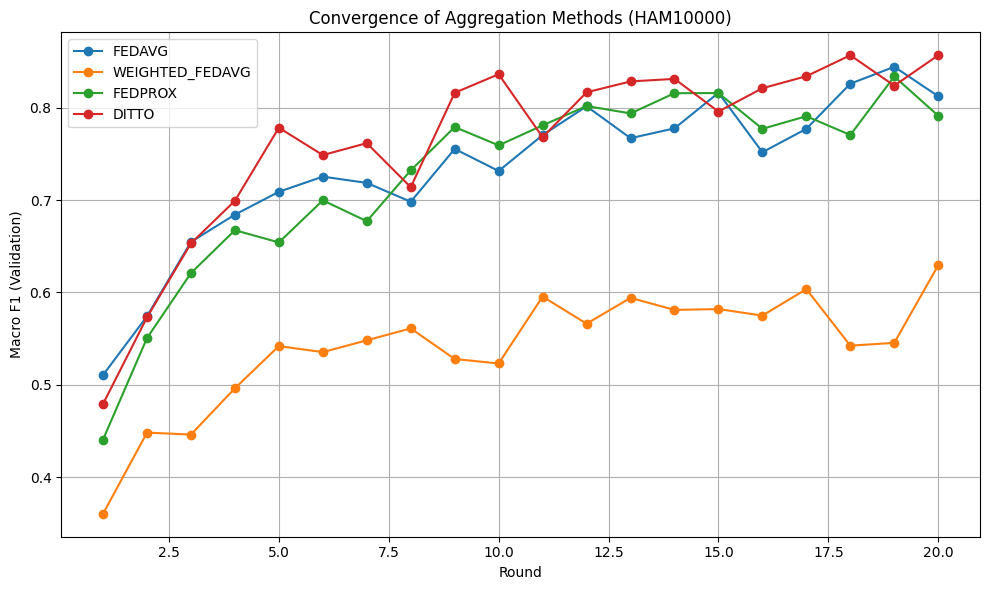

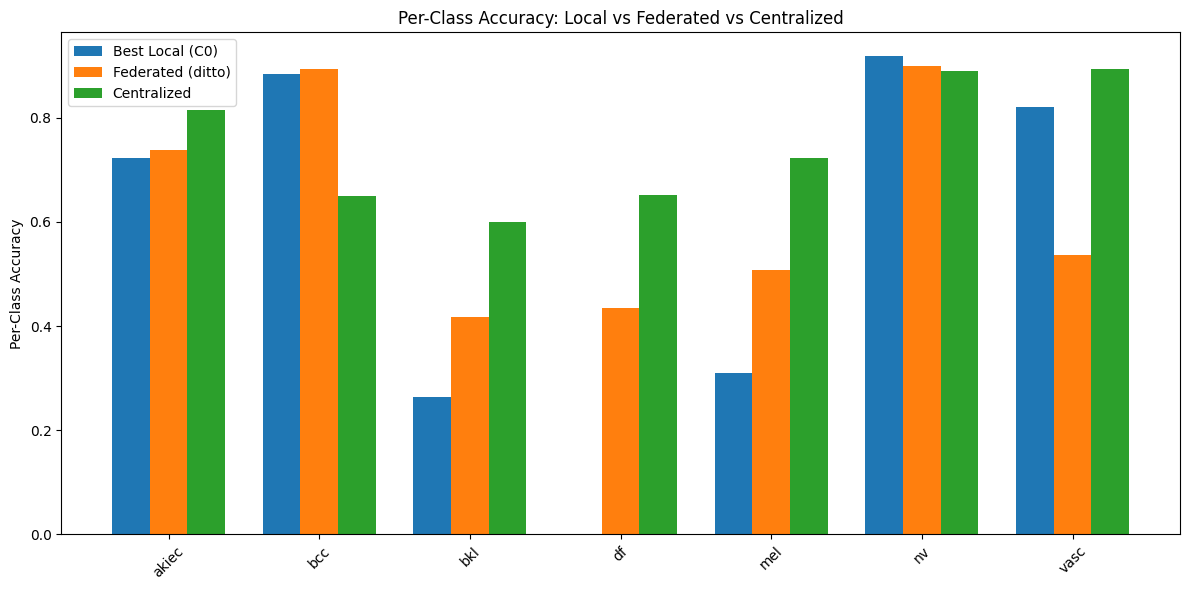

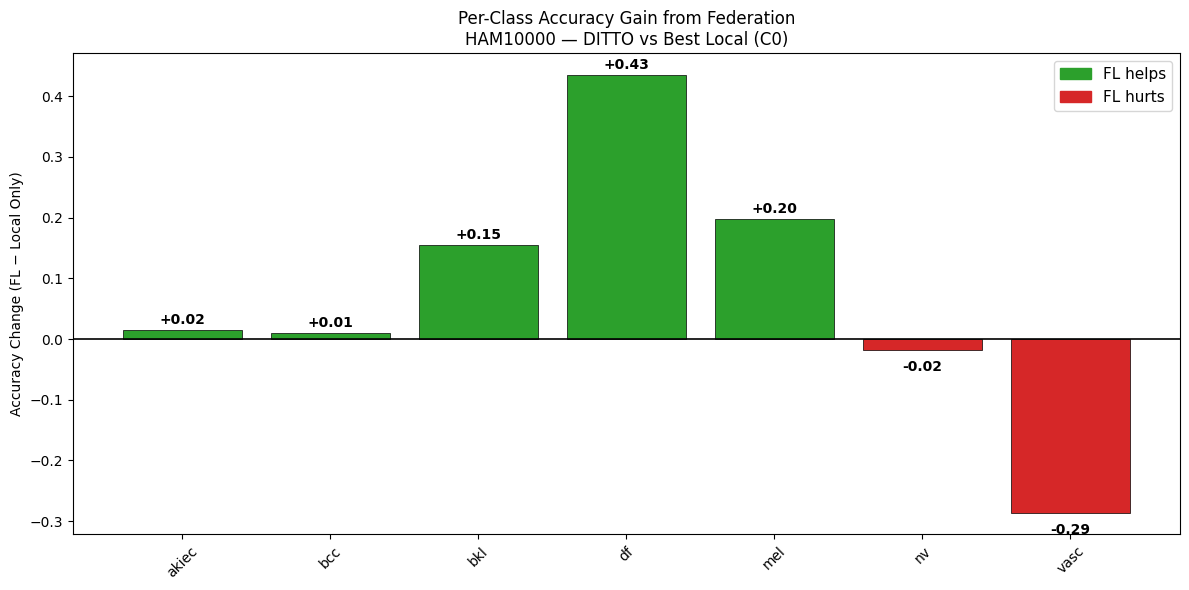

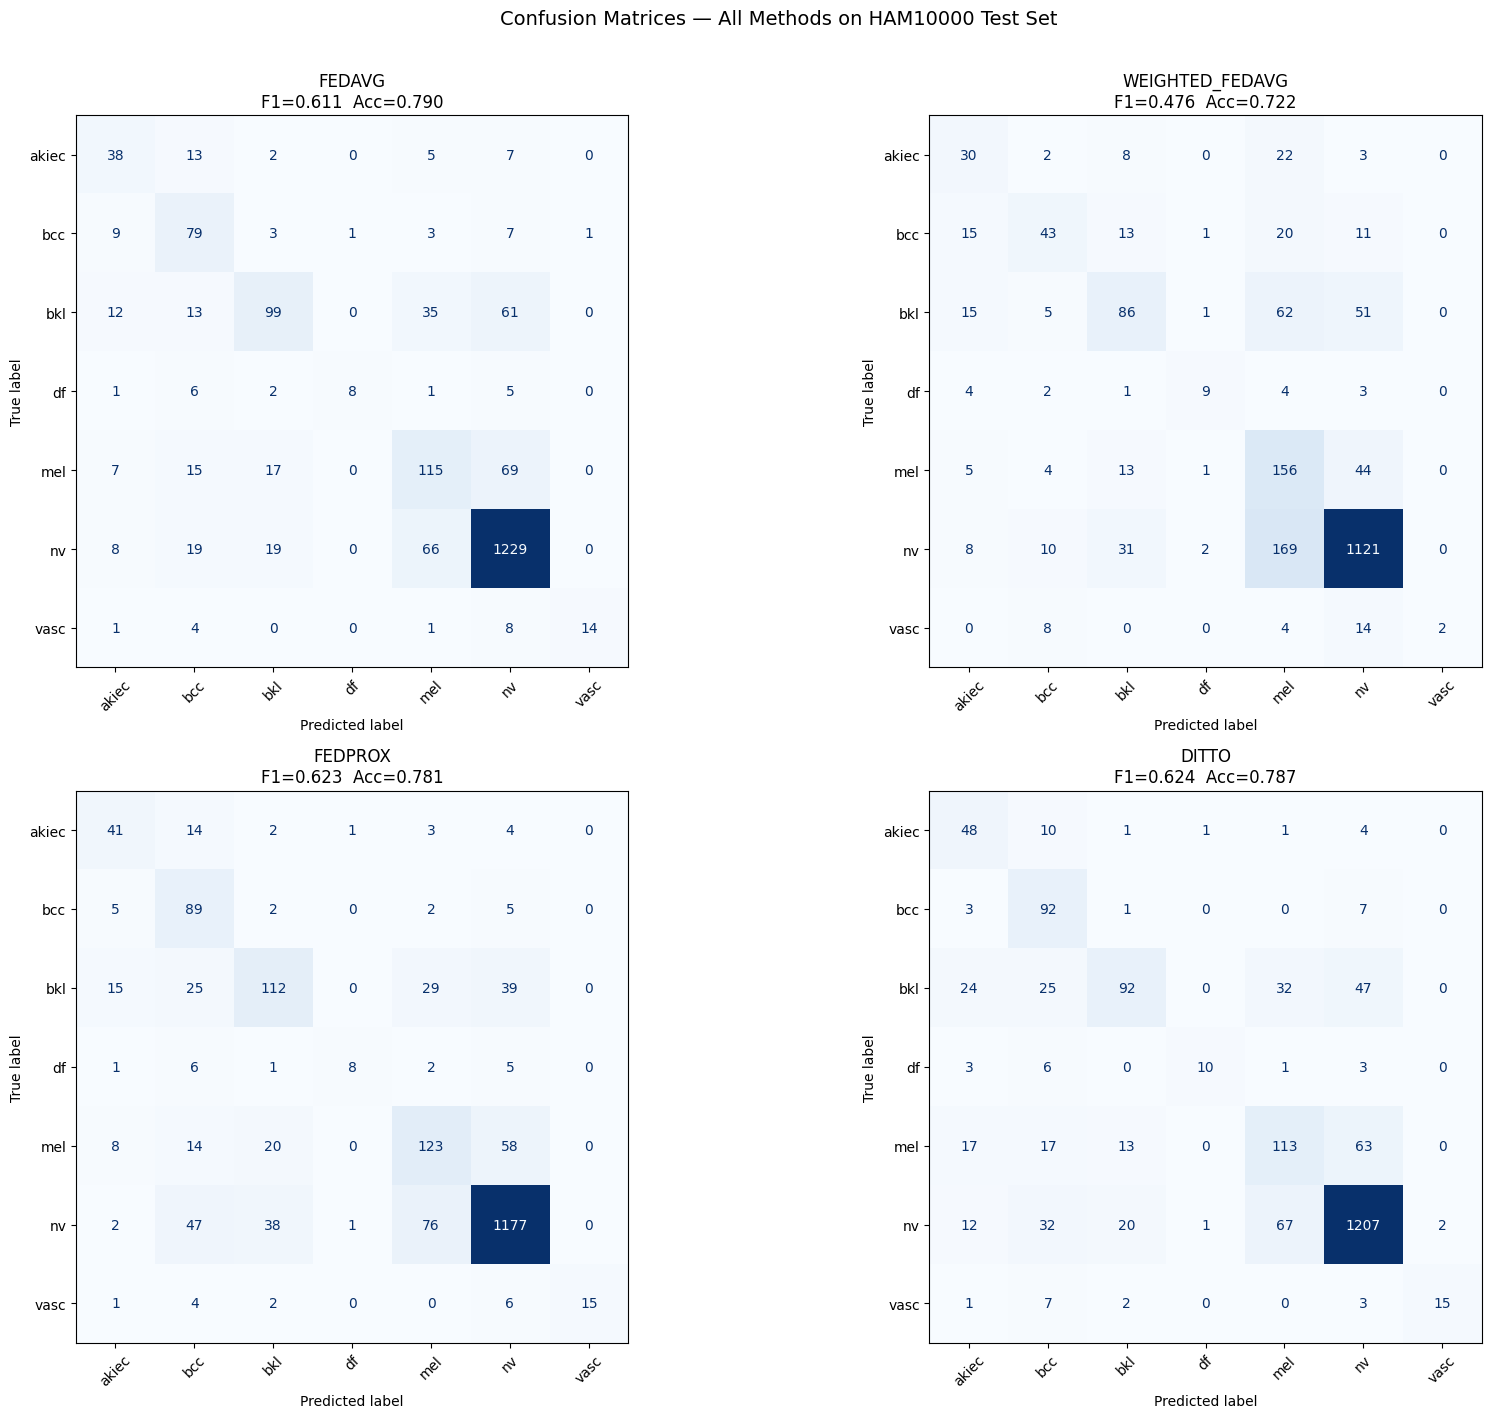

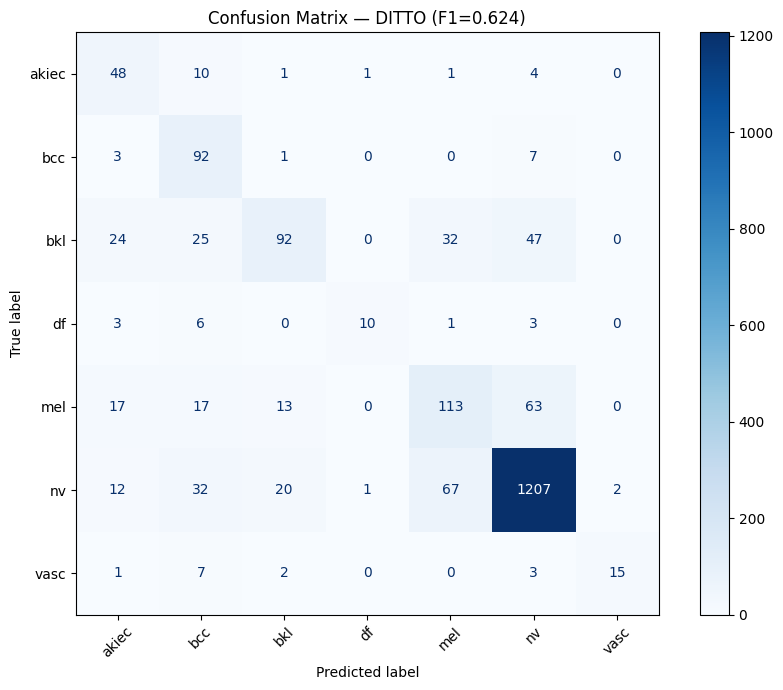

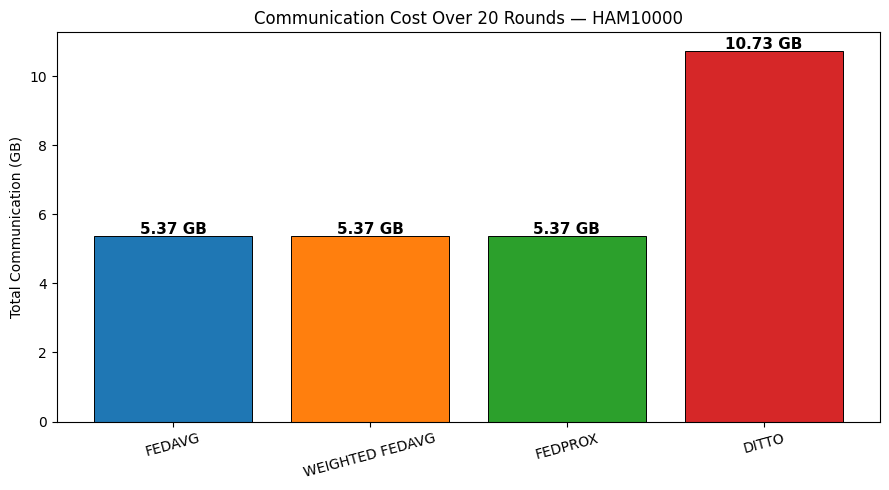

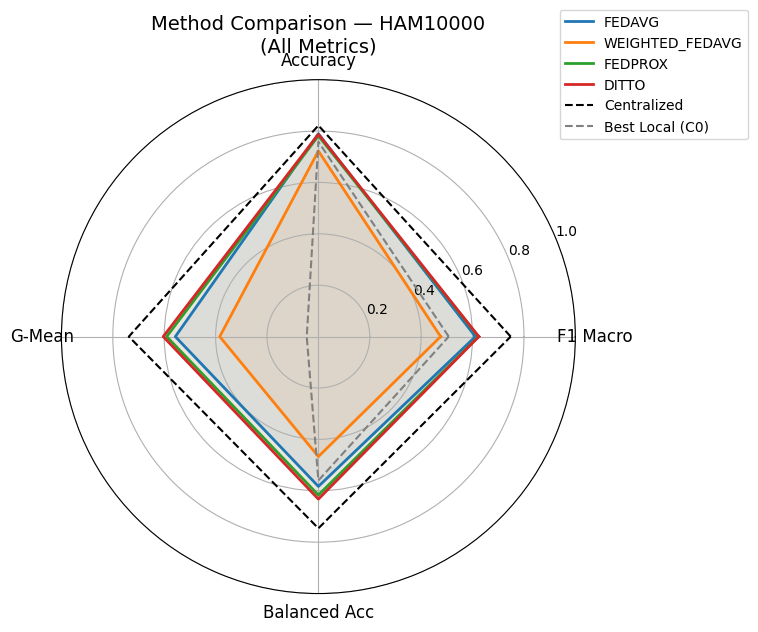

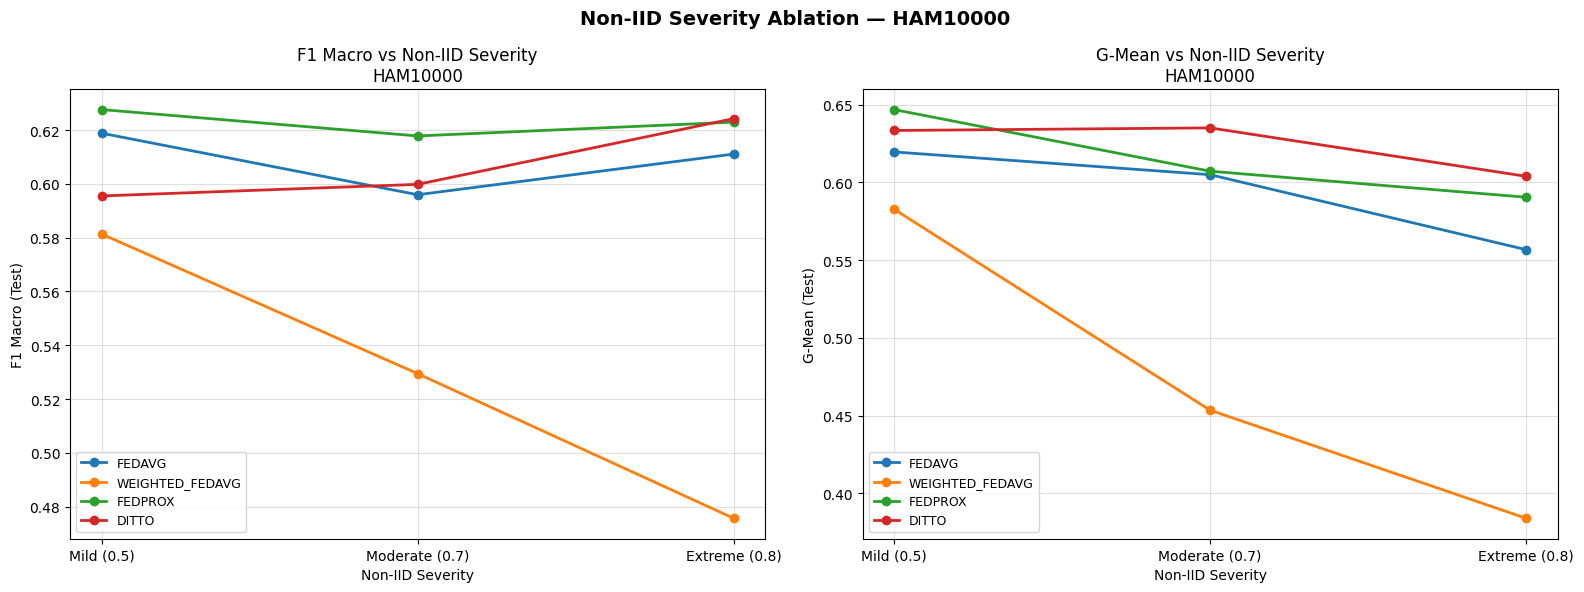


Ablation F1 Macro pivot:
majority_frac       0.5     0.7     0.8
method                                 
ditto            0.5955  0.5998  0.6243
fedavg           0.6189  0.5960  0.6111
fedprox          0.6276  0.6178  0.6230
weighted_fedavg  0.5814  0.5294  0.4757


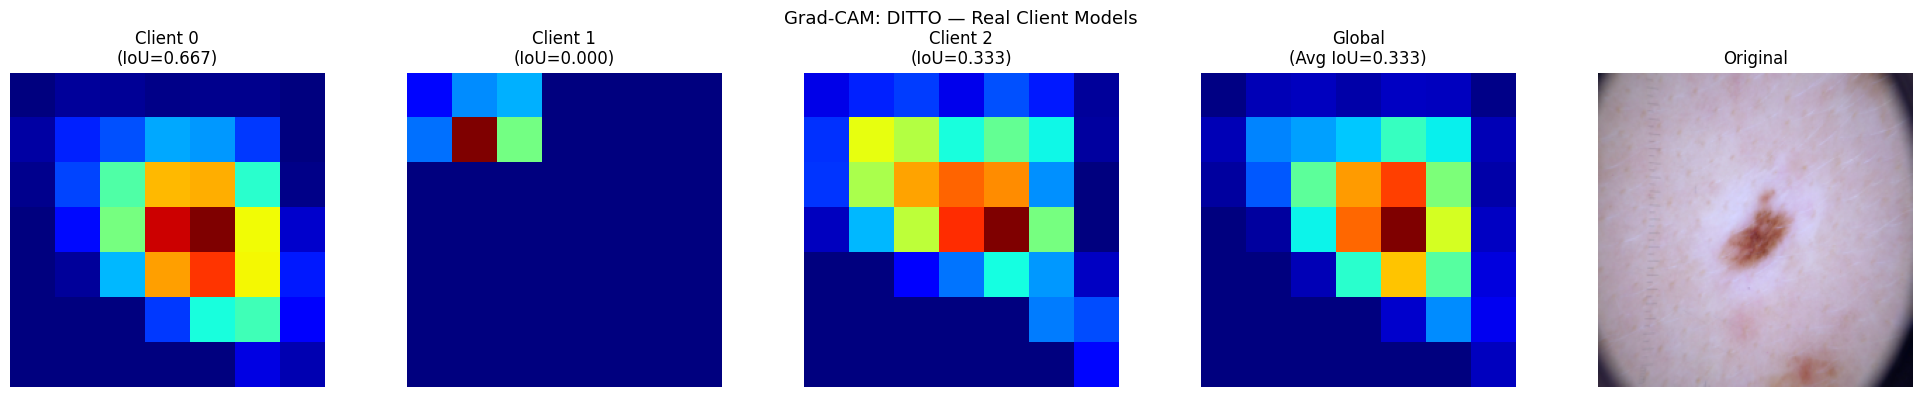


Generating CAM evolution across rounds...


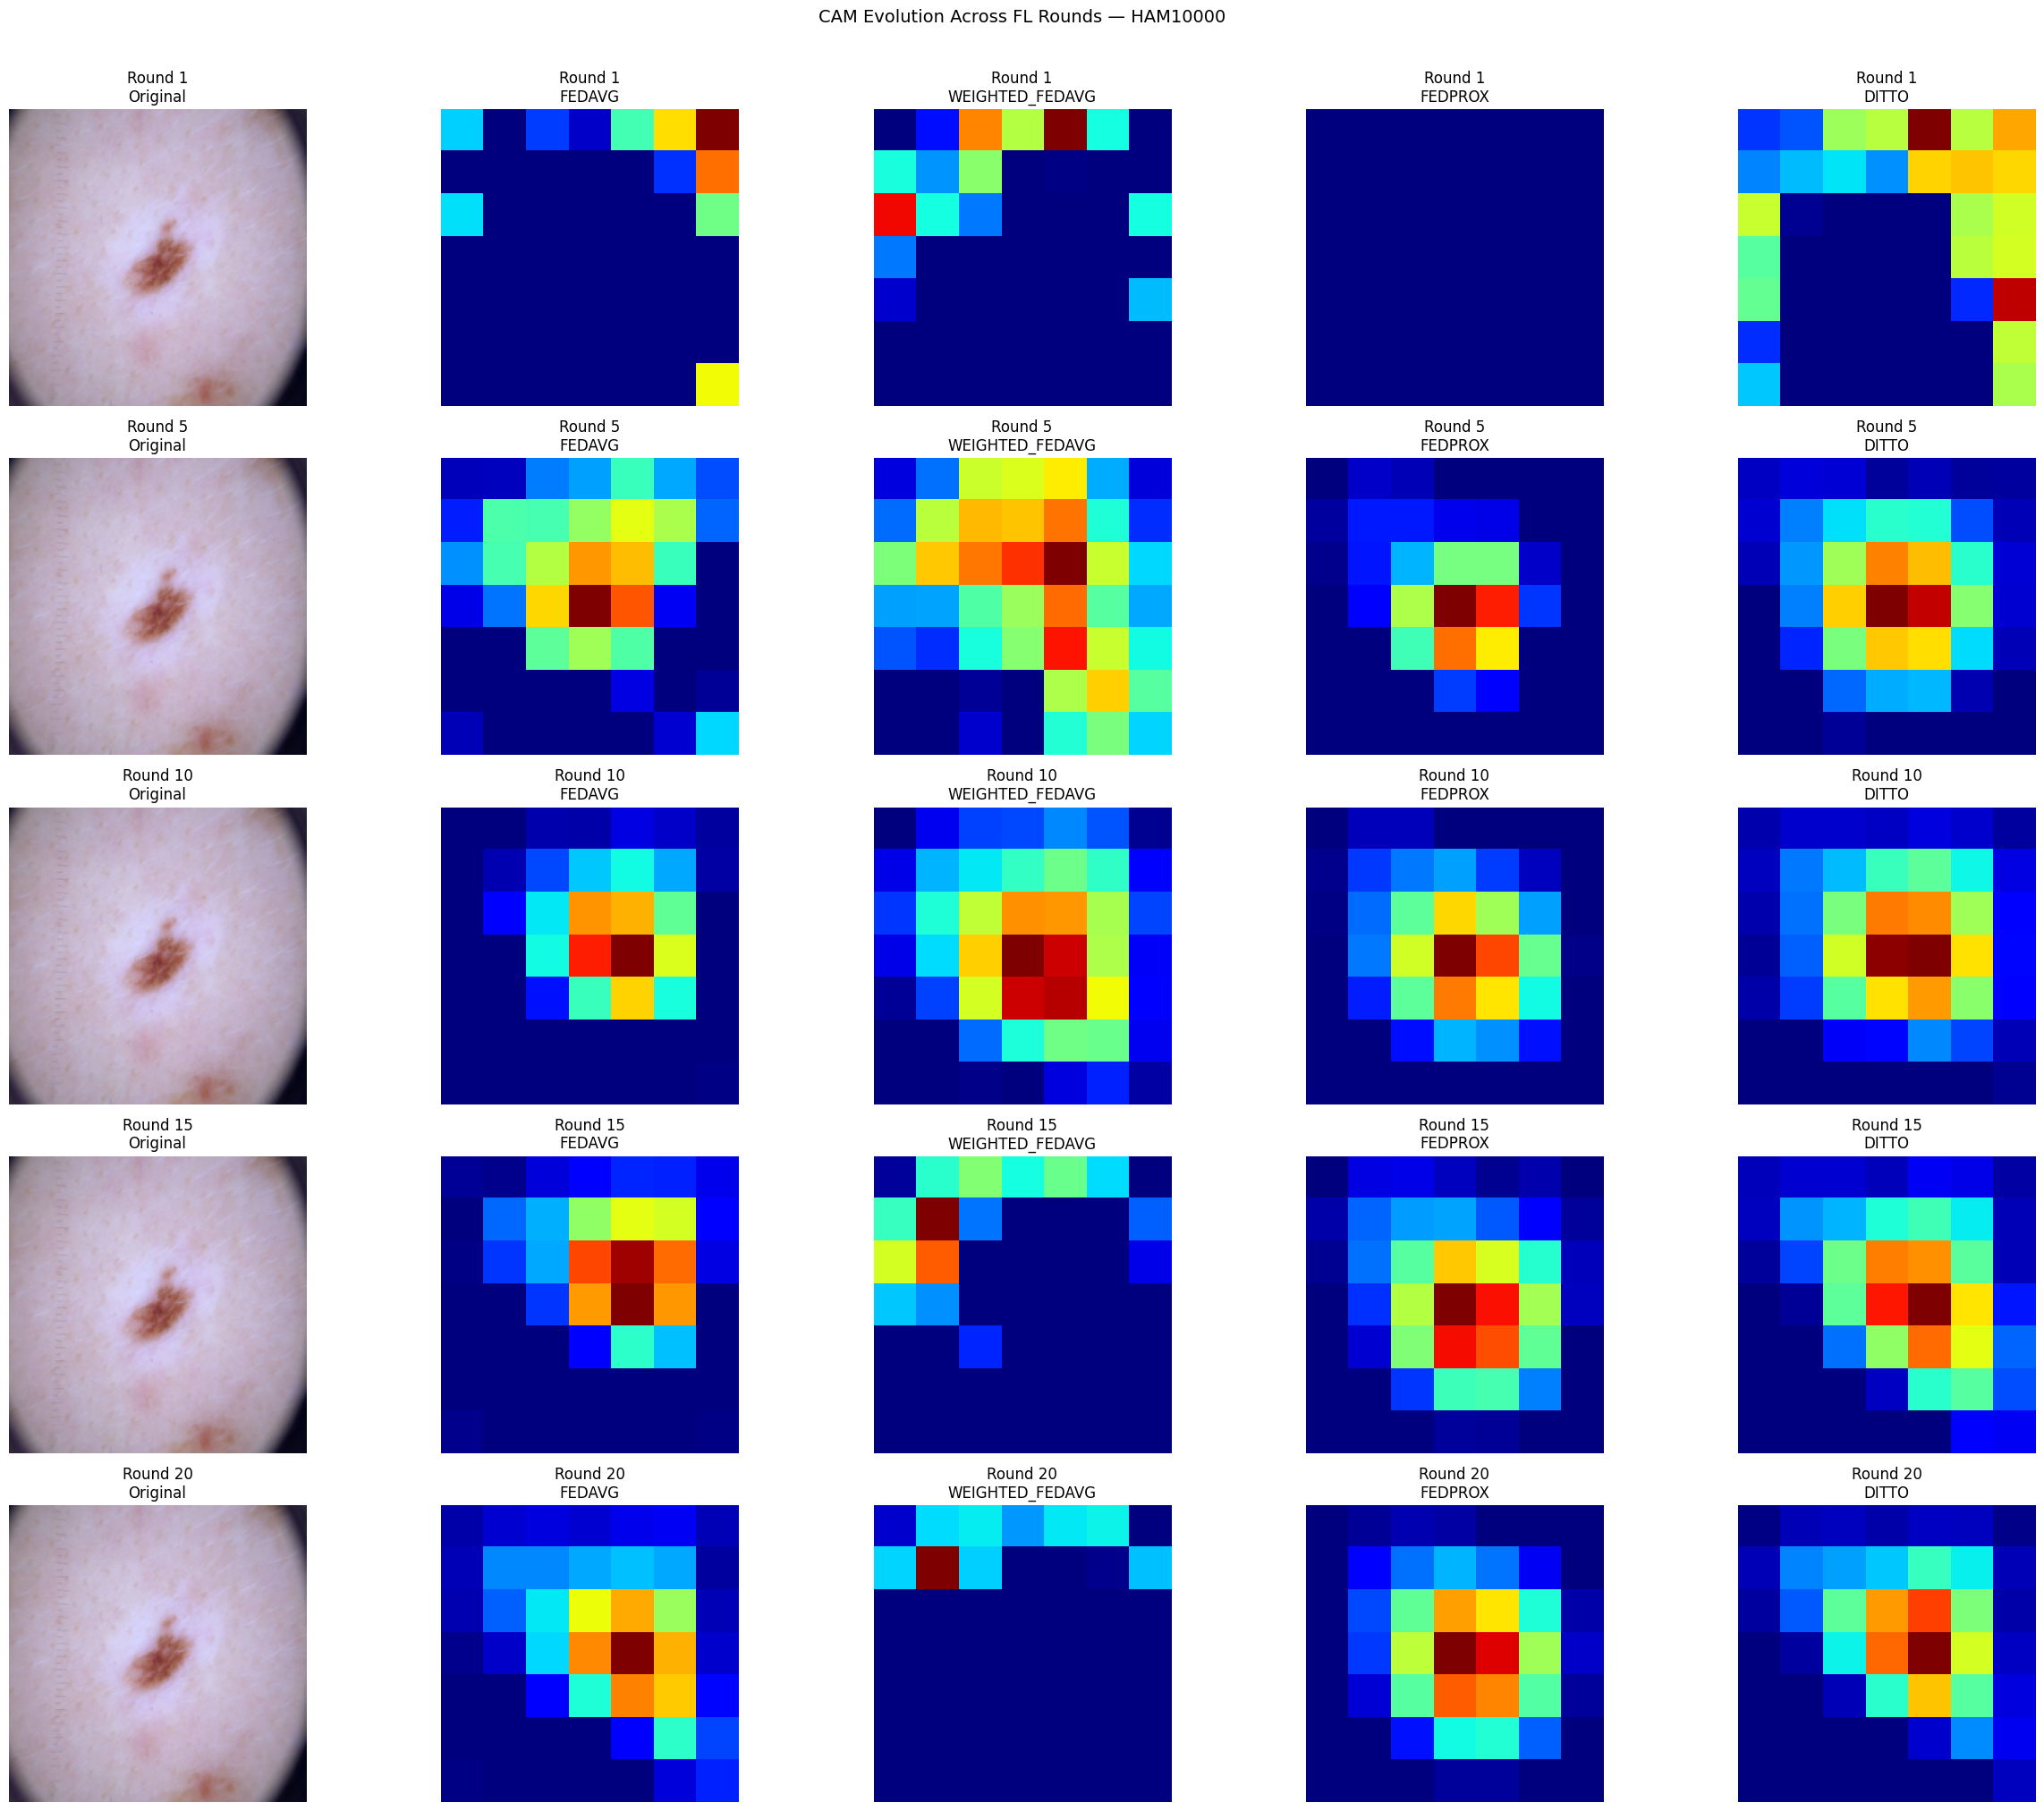

✅ CAM evolution saved.

Generating per-method CAM comparison...


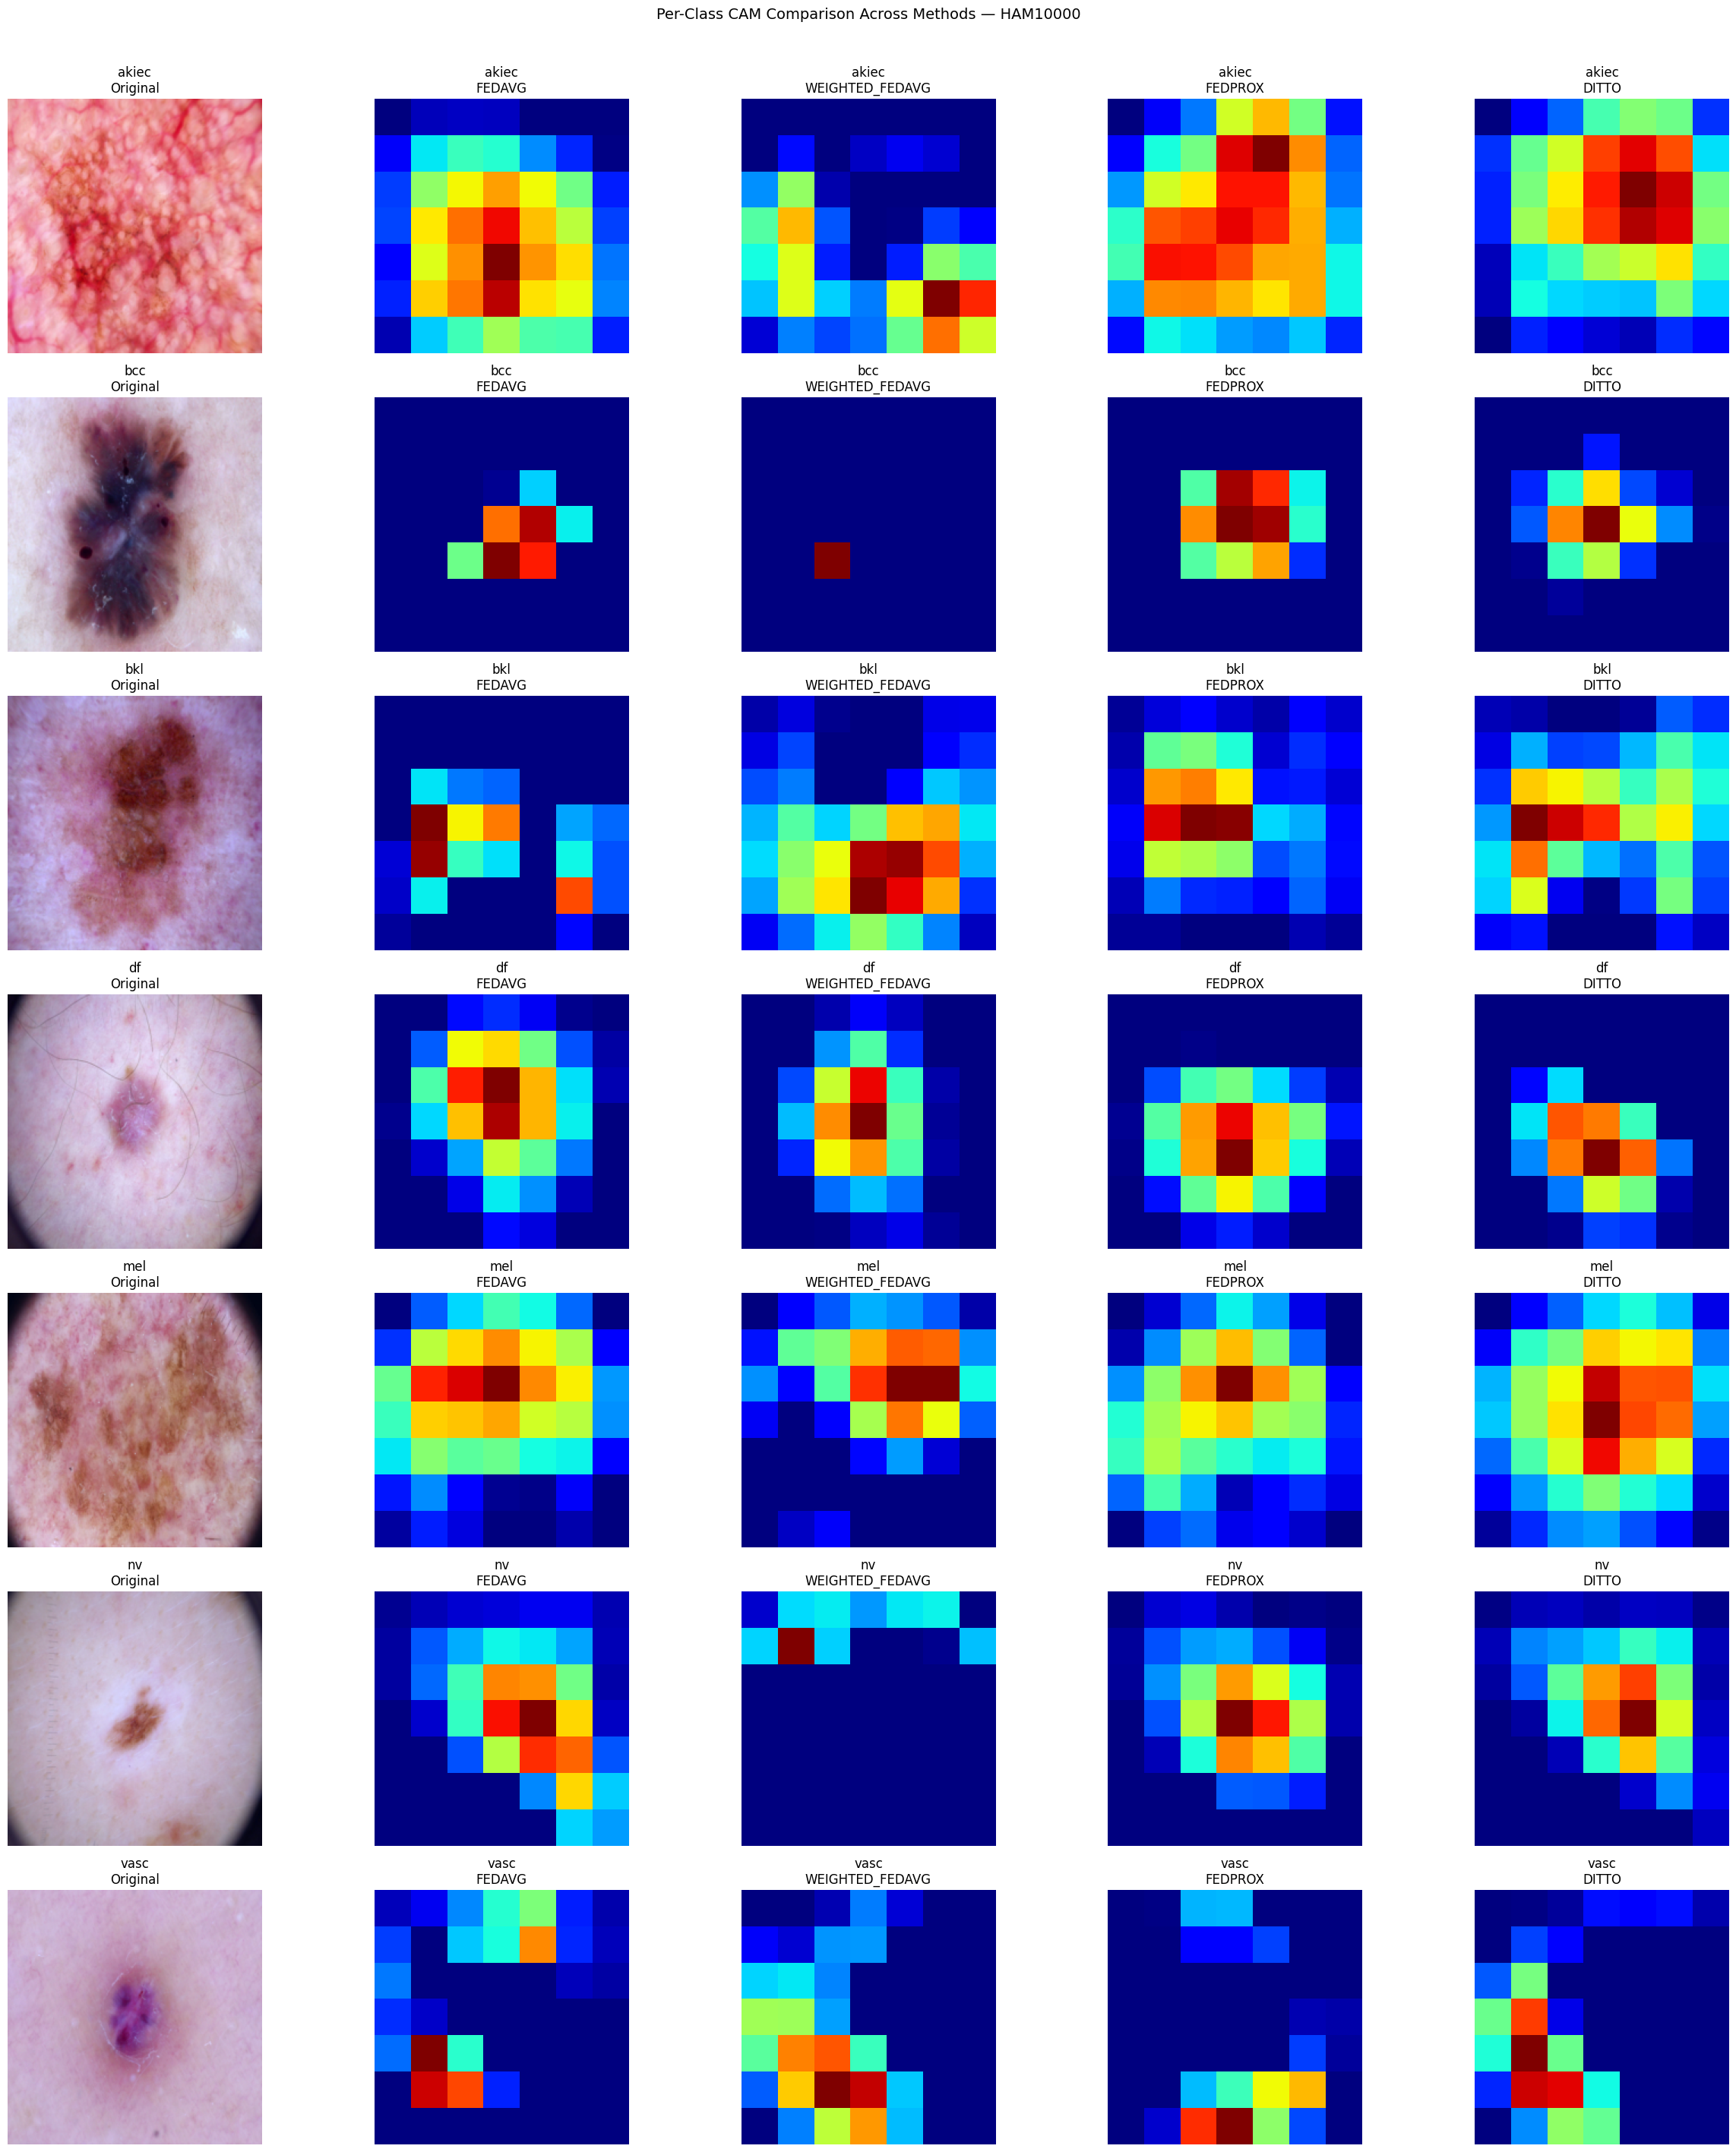

✅ Per-method CAM comparison saved.

MACHINE UNLEARNING
Forgetting: Client 2 (mel + nv dominant)
Base model: DITTO

Before unlearning:
  Forget C2 F1    : 0.7780
  Retain C0 F1    : 1.0000
  Retain C1 F1    : 0.6165
  Global F1       : 0.6243

Per-class F1 (original):
  akiec   : 0.5549
  bcc     : 0.6301
  bkl     : 0.5272
  df      : 0.5714
  mel     : 0.5172
  nv      : 0.9024
  vasc    : 0.6667

--- Approach A: Exact Unlearning (retrain 10 rounds) ---
  Round 1/10 → val F1:0.3879
  Round 2/10 → val F1:0.5424
  Round 3/10 → val F1:0.6025
  Round 4/10 → val F1:0.5891
  Round 5/10 → val F1:0.6685
  Round 6/10 → val F1:0.6130
  Round 7/10 → val F1:0.6425
  Round 8/10 → val F1:0.6405
  Round 9/10 → val F1:0.6672
  Round 10/10 → val F1:0.6793
  Forget C2 F1 : 0.4177  (Δ=-0.3604)
  Retain C0 F1 : 0.9955
  Retain C1 F1 : 0.6840
  Global F1    : 0.5948

--- Approach B: Gradient Ascent Unlearning ---
  Step 1: Gradient Ascent (50 steps)...
    Step 10: forget F1=0.7626
    Step 20: forget F1=

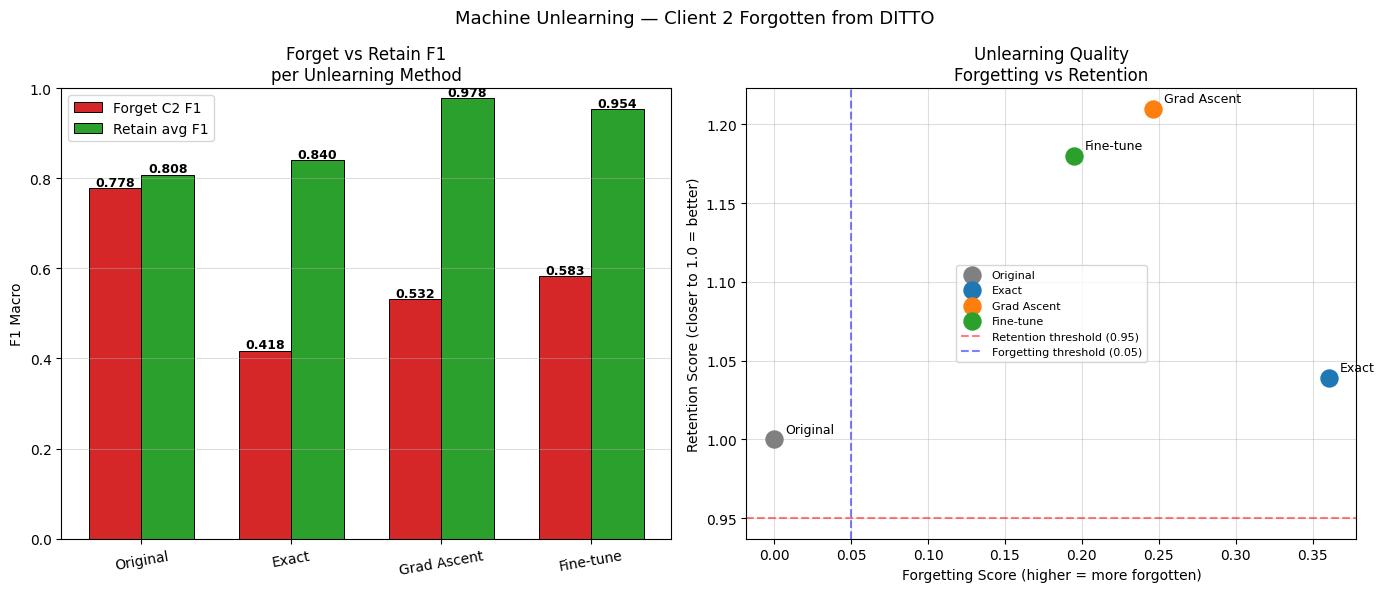

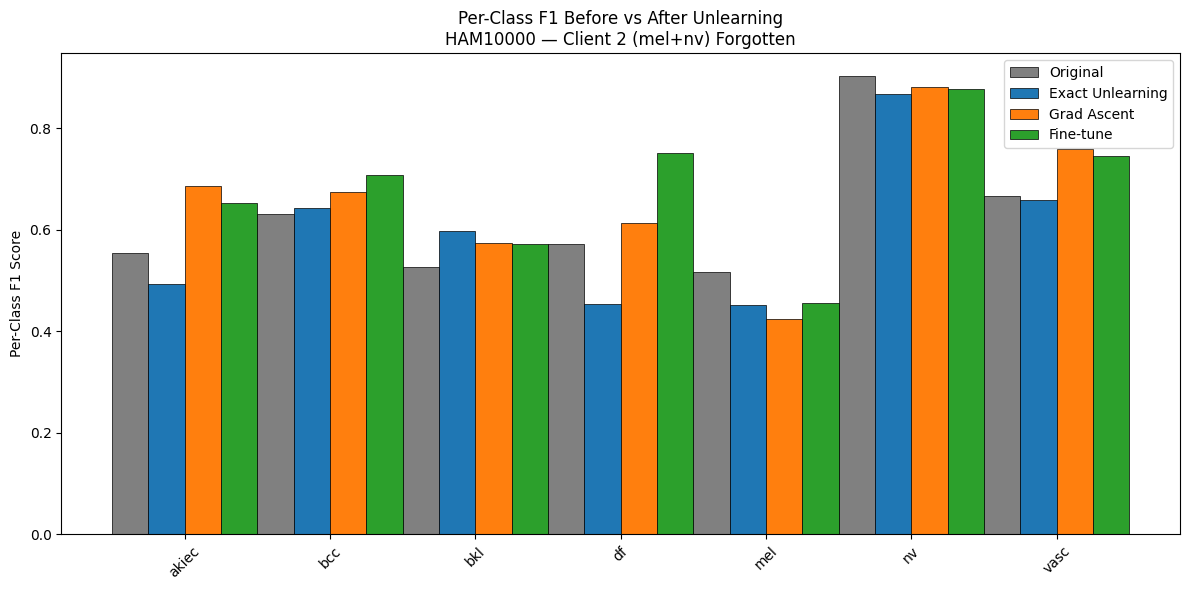


ALL OUTPUTS SAVED
  ✅ final_comparison_table.csv
  ✅ unlearning_results.csv
  ✅ ablation_results.csv
  ✅ ablation_pivot.csv
  ✅ communication_cost.csv
  ✅ convergence_clean.png
  ✅ per_class_comparison.png
  ✅ fl_gain_per_class.png
  ✅ confusion_matrices_all.png
  ✅ confusion_matrix_best.png
  ✅ communication_cost.png
  ✅ radar_chart.png
  ✅ ablation_severity.png
  ✅ gradcam_real_clients.png
  ✅ cam_evolution.png
  ✅ cam_per_method_comparison.png
  ✅ unlearning_comparison.png
  ✅ unlearning_per_class_f1.png


In [2]:
# ==========================================
# CELL 2: HAM10000 VALIDATION
# Includes:
#   - Final comparison table
#   - Grad-CAM IoU (50 images)
#   - Per-class comparison + FL gain chart
#   - Confusion matrices
#   - Communication cost
#   - Radar chart
#   - Ablation severity plot
#   - Machine Unlearning (3 approaches)
#   - CAM evolution across rounds
#   - Per-method CAM comparison
# ==========================================

!pip install -q kagglehub scikit-learn torchmetrics tqdm

import os, json, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from collections import OrderedDict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. RELOAD ASSETS FROM CELL 1
# ==========================================
with open("/kaggle/working/meta.json") as f:
    meta = json.load(f)

label_map                   = meta['label_map']
class_names                 = meta['class_names']
majority_classes_per_client = meta['majority_classes_per_client']
client_sizes_train          = meta['client_sizes']
checkpoint_rounds           = meta['checkpoint_rounds']
num_classes                 = len(class_names)
img1                        = meta['img_dir_1']
img2                        = meta['img_dir_2']

test_df  = pd.read_csv("/kaggle/working/test_df.csv")
train_df = pd.read_csv("/kaggle/working/train_df.csv")
client_dfs = [pd.read_csv(f"/kaggle/working/client_{i}_train.csv")
              for i in range(3)]
client_sizes = [len(c) for c in client_dfs]

print(f"Classes: {class_names}")
print(f"Test: {len(test_df)} | Train: {len(train_df)}")
print(f"Client sizes: {client_sizes}")

# ==========================================
# 2. IMAGE LOADING + TRANSFORMS
# ==========================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225]),
])

def load_image(img_id):
    p1 = os.path.join(img1, img_id + ".jpg")
    p2 = os.path.join(img2, img_id + ".jpg")
    try:
        return transform(
            Image.open(p1 if os.path.exists(p1) else p2).convert("RGB"))
    except Exception:
        return torch.zeros(3, 224, 224)

# Pre-load test images
print("Pre-loading test images...")
test_tensors = [load_image(r['image_id'])
                for _, r in tqdm(test_df.iterrows(),
                                 total=len(test_df))]
test_labels  = test_df['label'].tolist()

class InMemoryDataset(Dataset):
    def __init__(self, images, labels, noise_level=0.0):
        self.images=images; self.labels=labels
        self.noise_level=noise_level
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        img=self.images[idx].clone()
        if self.noise_level>0:
            img+=torch.randn_like(img)*self.noise_level/255.0
            img=torch.clamp(img,0,1)
        return img, self.labels[idx]

test_dataset = InMemoryDataset(test_tensors, test_labels)
test_loader  = DataLoader(test_dataset, batch_size=32,
                          shuffle=False, num_workers=2,
                          pin_memory=True)

# Per-client test loaders for unlearning
client_test_loaders = []
for i in range(3):
    cdf_test = pd.read_csv(
        f"/kaggle/working/client_{i}_test_split.csv")
    imgs = [load_image(r['image_id'])
            for _, r in cdf_test.iterrows()]
    lbls = cdf_test['label'].tolist()
    loader = DataLoader(InMemoryDataset(imgs, lbls),
                        batch_size=32, shuffle=False,
                        num_workers=2, pin_memory=True)
    client_test_loaders.append(loader)

# ==========================================
# 3. MODEL + METRICS
# ==========================================
def get_model():
    m    = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m.to(device)

def evaluate_model(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            preds = torch.argmax(
                F.softmax(model(x), dim=1), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())
    y_true, y_pred = np.array(all_labels), np.array(all_preds)
    pc_acc, pc_rec = [], []
    for c in range(num_classes):
        idx = y_true==c
        pc_acc.append(float(np.mean(y_pred[idx]==c))
                      if idx.sum()>0 else 0.0)
        tp = np.sum((y_pred==c)&(y_true==c))
        fn = np.sum((y_pred!=c)&(y_true==c))
        pc_rec.append(tp/(tp+fn) if (tp+fn)>0 else 0.0)
    return {
        'accuracy':           float(accuracy_score(y_true,y_pred)),
        'f1_macro':           float(f1_score(y_true,y_pred,
                                   average='macro',zero_division=0)),
        'f1_per_class':       f1_score(y_true,y_pred,
                                   average=None,zero_division=0).tolist(),
        'balanced_accuracy':  float(balanced_accuracy_score(y_true,y_pred)),
        'g_mean':             float(np.exp(np.mean(
                                   np.log([r+1e-8 for r in pc_rec])))),
        'per_class_accuracy': pc_acc,
        'y_true':             y_true.tolist(),
        'y_pred':             y_pred.tolist(),
    }

# ==========================================
# 4. GRAD-CAM + IoU
# ==========================================
def grad_cam(model, img_tensor, target_class,
             target_layer='layer4'):
    model.eval()
    img_t = img_tensor.unsqueeze(0).to(device).requires_grad_(True)
    grads, acts = [], []
    def bwd(m,gi,go): grads.append(go[0])
    def fwd(m,i,o):   acts.append(o)
    tm = dict(model.named_modules()).get(target_layer)
    h1 = tm.register_forward_hook(fwd)
    h2 = tm.register_backward_hook(bwd)
    out = model(img_t); out[0, target_class].backward()
    h1.remove(); h2.remove()
    grad    = grads[0].cpu().detach().numpy()[0]
    act     = acts[0].cpu().detach().numpy()[0]
    weights = np.mean(grad, axis=(1,2))
    cam     = np.maximum(
        np.sum([w*a for w,a in zip(weights,act)], axis=0), 0)
    cam = (cam-cam.min())/(cam.max()-cam.min()+1e-8)
    return cam

def compute_iou(m1, m2, threshold=0.5):
    b1=(m1>threshold).astype(np.uint8)
    b2=(m2>threshold).astype(np.uint8)
    inter=np.logical_and(b1,b2).sum()
    union=np.logical_or(b1,b2).sum()
    return (inter/union) if union>0 else (1.0 if inter==0 else 0.0)

def compute_avg_iou(global_model, client_models,
                    dataset, n_samples=50, threshold=0.5):
    np.random.seed(42)
    indices  = np.random.choice(len(dataset), n_samples, replace=False)
    all_ious = [[] for _ in client_models]
    for idx in indices:
        img, label = dataset[idx]
        g_cam = grad_cam(global_model, img.to(device), label)
        for cid, cm in enumerate(client_models):
            c_cam = grad_cam(cm, img.to(device), label)
            all_ious[cid].append(
                compute_iou(g_cam, c_cam, threshold))
    per_client = [float(np.mean(v)) for v in all_ious]
    return float(np.mean(per_client)), per_client

# ==========================================
# 5. LOAD ALL FL MODELS
# ==========================================
METHOD_NAMES     = ['fedavg','weighted_fedavg','fedprox','ditto']
fl_models        = {}
fl_client_models = {}

print("\nLoading FL models...")
for name in METHOD_NAMES:
    gm = get_model()
    gm.load_state_dict(torch.load(
        f"/kaggle/working/final_model_{name}.pth",
        map_location=device))
    fl_models[name] = gm

    clist = []
    for cid in range(3):
        cm = get_model()
        cm.load_state_dict(torch.load(
            f"/kaggle/working/client_{name}_{cid}.pth",
            map_location=device))
        clist.append(cm)
    fl_client_models[name] = clist

    m = evaluate_model(gm, test_loader)
    print(f"  ✅ {name} → F1={m['f1_macro']:.4f}  "
          f"Acc={m['accuracy']:.4f}")

# ==========================================
# 6. CENTRALIZED BASELINE
# ==========================================
print("\nTraining centralized model (3 epochs)...")

# Pre-load train images
print("Pre-loading train images...")
train_tensors = [load_image(r['image_id'])
                 for _, r in tqdm(train_df.iterrows(),
                                  total=len(train_df))]
train_labels_all = train_df['label'].tolist()

class_counts    = np.bincount(train_labels_all, minlength=num_classes)
class_weights_t = torch.tensor(
    1.0/class_counts/(1.0/class_counts).sum(),
    dtype=torch.float32).to(device)

c_sw = 1.0/class_counts[train_labels_all]
c_sw /= c_sw.sum()
c_sampler = WeightedRandomSampler(c_sw, len(c_sw), replacement=True)
c_loader  = DataLoader(
    InMemoryDataset(train_tensors, train_labels_all),
    batch_size=32, sampler=c_sampler,
    num_workers=2, pin_memory=True)

central_model = get_model()
c_opt  = optim.Adam(central_model.parameters(), lr=1e-4)
c_crit = nn.CrossEntropyLoss()
for epoch in range(3):
    central_model.train()
    for x, y in tqdm(c_loader, desc=f"Central {epoch+1}",
                     leave=False):
        x, y = x.to(device), y.to(device)
        c_opt.zero_grad()
        c_crit(central_model(x), y).backward()
        c_opt.step()

central_metrics = evaluate_model(central_model, test_loader)
print(f"Centralized → F1={central_metrics['f1_macro']:.4f}  "
      f"Acc={central_metrics['accuracy']:.4f}")
del c_loader; torch.cuda.empty_cache()

# ==========================================
# 7. LOCAL-ONLY BASELINES
# ==========================================
def disjoint_non_iid_split(labels, majority_per_client,
                            majority_frac=0.8, seed=42):
    np.random.seed(seed)
    labels_arr = np.array(labels)
    n_clients  = len(majority_per_client)
    assigned   = np.full(len(labels), -1, dtype=int)
    for class_id in range(num_classes):
        pos = np.where(labels_arr==class_id)[0].tolist()
        np.random.shuffle(pos)
        owner = next(
            (c for c,g in enumerate(majority_per_client)
             if class_id in g), 0)
        n_maj = int(len(pos)*majority_frac)
        for i in pos[:n_maj]: assigned[i]=owner
        others=[c for c in range(n_clients) if c!=owner]
        for c,chunk in zip(others,
                np.array_split(pos[n_maj:],max(len(others),1))):
            for i in chunk: assigned[i]=c
    assigned[assigned==-1]=0
    return [np.where(assigned==c)[0].tolist()
            for c in range(n_clients)]

client_indices_local = disjoint_non_iid_split(
    train_labels_all, majority_classes_per_client,
    majority_frac=0.8)

print("\nTraining local-only models...")
local_models, local_metrics = [], []
NOISE_LEVELS = [0.0, 20.0, 10.0]

for cid, idx in enumerate(client_indices_local):
    imgs = [train_tensors[i] for i in idx]
    lbls = [train_labels_all[i] for i in idx]
    counts = np.bincount(lbls, minlength=num_classes)
    sw = 1.0/counts[lbls]; sw /= sw.sum()
    sampler = WeightedRandomSampler(sw, len(sw), replacement=True)
    loader  = DataLoader(
        InMemoryDataset(imgs, lbls, NOISE_LEVELS[cid]),
        batch_size=32, sampler=sampler,
        num_workers=2, pin_memory=True)
    model = get_model()
    opt   = optim.Adam(model.parameters(), lr=1e-4)
    crit  = nn.CrossEntropyLoss()
    for epoch in range(3):
        model.train()
        for x, y in tqdm(loader,
                         desc=f"Local C{cid} ep{epoch+1}",
                         leave=False):
            x, y = x.to(device), y.to(device)
            opt.zero_grad(); crit(model(x),y).backward(); opt.step()
    m = evaluate_model(model, test_loader)
    local_models.append(model); local_metrics.append(m)
    print(f"  C{cid} local → F1={m['f1_macro']:.4f}  "
          f"Acc={m['accuracy']:.4f}")
    del loader; torch.cuda.empty_cache()

# ==========================================
# 8. GRAD-CAM IoU (50 test images)
# ==========================================
print("\nComputing Grad-CAM IoU (50 images per method)...")
iou_results = {}
for name in METHOD_NAMES:
    avg_iou, per_client = compute_avg_iou(
        fl_models[name], fl_client_models[name],
        test_dataset, n_samples=50)
    iou_results[name] = {'avg': avg_iou, 'per_client': per_client}
    print(f"  {name}: avg={avg_iou:.4f}  "
          f"per-client={[f'{v:.3f}' for v in per_client]}")

# ==========================================
# 9. FINAL COMPARISON TABLE
# ==========================================
best_local_idx = int(np.argmax([m['f1_macro'] for m in local_metrics]))
bl             = local_metrics[best_local_idx]

print("\n===== FINAL TEST METRICS =====")
print(f"{'Method':<25} {'Acc':<8} {'F1':<8} "
      f"{'G-mean':<10} {'BalAcc':<10} {'IoU'}")
print("-"*75)

table_data = []
for label, m, iou in (
    [('Centralized', central_metrics, None),
     (f'Best Local (C{best_local_idx})', bl, None)] +
    [(n, evaluate_model(fl_models[n], test_loader),
      iou_results[n]['avg']) for n in METHOD_NAMES]
):
    iou_s = f"{iou:.4f}" if iou else "N/A"
    print(f"{label:<25} {m['accuracy']:.4f}   "
          f"{m['f1_macro']:.4f}   {m['g_mean']:.4f}     "
          f"{m['balanced_accuracy']:.4f}     {iou_s}")
    table_data.append({
        'Method':       label,
        'Accuracy':     m['accuracy'],
        'F1_macro':     m['f1_macro'],
        'G_mean':       m['g_mean'],
        'Balanced_Acc': m['balanced_accuracy'],
        'IoU':          iou,
    })

pd.DataFrame(table_data).to_csv(
    "/kaggle/working/final_comparison_table.csv", index=False)

best_fl_name = max(METHOD_NAMES,
    key=lambda n: evaluate_model(fl_models[n],test_loader)['f1_macro'])
best_fl_f1   = evaluate_model(fl_models[best_fl_name],
                               test_loader)['f1_macro']
print(f"\n✅ Best FL ({best_fl_name}) vs local: "
      f"{(best_fl_f1-bl['f1_macro'])/bl['f1_macro']*100:.1f}%")

# ==========================================
# 10. CONVERGENCE PLOT
# ==========================================
df_results = pd.read_csv(
    "/kaggle/working/fl_results_all_methods.csv")
colors = {'fedavg':'#1f77b4','weighted_fedavg':'#ff7f0e',
          'fedprox':'#2ca02c','ditto':'#d62728'}
plt.figure(figsize=(10,6))
for name in METHOD_NAMES:
    sub = df_results[df_results['aggregation']==name]
    plt.plot(sub['round']+1, sub['f1_macro'],
             marker='o', color=colors[name], label=name.upper())
plt.xlabel('Round'); plt.ylabel('Macro F1 (Validation)')
plt.title('Convergence of Aggregation Methods (HAM10000)')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("/kaggle/working/convergence_clean.png", dpi=150)
plt.show()

# ==========================================
# 11. PER-CLASS COMPARISON
# ==========================================
best_fl_metrics = evaluate_model(fl_models[best_fl_name], test_loader)
x = np.arange(num_classes); w = 0.25
fig, ax = plt.subplots(figsize=(12,6))
ax.bar(x-w, bl['per_class_accuracy'], w,
       label=f'Best Local (C{best_local_idx})')
ax.bar(x,   best_fl_metrics['per_class_accuracy'], w,
       label=f'Federated ({best_fl_name})')
ax.bar(x+w, central_metrics['per_class_accuracy'], w,
       label='Centralized')
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=45)
ax.set_ylabel('Per-Class Accuracy')
ax.set_title('Per-Class Accuracy: Local vs Federated vs Centralized')
ax.legend(); plt.tight_layout()
plt.savefig("/kaggle/working/per_class_comparison.png", dpi=150)
plt.show()

# ==========================================
# 12. FL GAIN PER CLASS
# ==========================================
local_acc = bl['per_class_accuracy']
fl_acc    = best_fl_metrics['per_class_accuracy']
delta     = [f-l for f,l in zip(fl_acc, local_acc)]
bar_colors = ['#2ca02c' if d>0 else '#d62728' for d in delta]

fig, ax = plt.subplots(figsize=(12,6))
bars = ax.bar(range(num_classes), delta,
              color=bar_colors, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=1.2)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45)
ax.set_ylabel('Accuracy Change (FL − Local Only)')
ax.set_title(f'Per-Class Accuracy Gain from Federation\n'
             f'HAM10000 — {best_fl_name.upper()} vs '
             f'Best Local (C{best_local_idx})')
for bar, d in zip(bars, delta):
    ypos = bar.get_height()+0.01 if d>=0 else bar.get_height()-0.035
    ax.text(bar.get_x()+bar.get_width()/2, ypos,
            f'{d:+.2f}', ha='center', fontsize=10, fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#2ca02c', label='FL helps'),
    mpatches.Patch(color='#d62728', label='FL hurts'),
], fontsize=11)
plt.tight_layout()
plt.savefig("/kaggle/working/fl_gain_per_class.png", dpi=150)
plt.show()

# ==========================================
# 13. CONFUSION MATRICES
# ==========================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, axes = plt.subplots(2,2,figsize=(18,14))
axes = axes.flatten()
for ax, name in zip(axes, METHOD_NAMES):
    m  = evaluate_model(fl_models[name], test_loader)
    cm = confusion_matrix(m['y_true'], m['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
    ax.set_title(f'{name.upper()}\n'
                 f'F1={m["f1_macro"]:.3f}  Acc={m["accuracy"]:.3f}')
plt.suptitle('Confusion Matrices — All Methods on HAM10000 Test Set',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices_all.png",
            dpi=150, bbox_inches='tight')
plt.show()

best_m = evaluate_model(fl_models[best_fl_name], test_loader)
cm     = confusion_matrix(best_m['y_true'], best_m['y_pred'])
fig, ax = plt.subplots(figsize=(9,7))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', xticks_rotation=45, colorbar=True)
ax.set_title(f'Confusion Matrix — {best_fl_name.upper()} '
             f'(F1={best_m["f1_macro"]:.3f})')
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_best.png", dpi=150)
plt.show()

# ==========================================
# 14. COMMUNICATION COST
# ==========================================
def comm_cost(rounds=20, n_clients=3, multiplier=1):
    params = sum(p.numel() for p in get_model().parameters())
    return (params*4*2*n_clients*rounds*multiplier)/1e9

costs = [comm_cost(multiplier=2 if n=='ditto' else 1)
         for n in METHOD_NAMES]
fig, ax = plt.subplots(figsize=(9,5))
color_list = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
bars = ax.bar(METHOD_NAMES, costs, color=color_list,
              edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, costs):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.05,
            f'{val:.2f} GB', ha='center',
            fontsize=11, fontweight='bold')
ax.set_ylabel('Total Communication (GB)')
ax.set_title('Communication Cost Over 20 Rounds — HAM10000')
ax.set_xticklabels(
    [n.replace('_',' ').upper() for n in METHOD_NAMES],
    rotation=15)
plt.tight_layout()
plt.savefig("/kaggle/working/communication_cost.png", dpi=150)
plt.show()

pd.DataFrame([{
    'Method': n,
    'Total_GB': f"{comm_cost(multiplier=2 if n=='ditto' else 1):.2f}",
    'Note': '2× (global+personal)' if n=='ditto' else 'standard'
} for n in METHOD_NAMES]).to_csv(
    "/kaggle/working/communication_cost.csv", index=False)

# ==========================================
# 15. RADAR CHART
# ==========================================
radar_metrics = ['F1 Macro','Accuracy','G-Mean','Balanced Acc']
n      = len(radar_metrics)
angles = np.linspace(0,2*np.pi,n,endpoint=False).tolist()
angles+= angles[:1]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
for name, color in zip(METHOD_NAMES, color_list):
    m = evaluate_model(fl_models[name], test_loader)
    vals = [m['f1_macro'], m['accuracy'],
            m['g_mean'],   m['balanced_accuracy']]
    vals+= vals[:1]
    ax.plot(angles,vals,color=color,linewidth=2,label=name.upper())
    ax.fill(angles,vals,color=color,alpha=0.08)

for ref, label, clr in [
    (central_metrics,'Centralized','black'),
    (bl,f'Best Local (C{best_local_idx})','grey')]:
    vals=[ref['f1_macro'],ref['accuracy'],
          ref['g_mean'],  ref['balanced_accuracy']]
    vals+=vals[:1]
    ax.plot(angles,vals,color=clr,linewidth=1.5,
            linestyle='--',label=label)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, size=12)
ax.set_ylim(0,1)
ax.set_title('Method Comparison — HAM10000\n(All Metrics)',
             size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35,1.15), fontsize=10)
plt.tight_layout()
plt.savefig("/kaggle/working/radar_chart.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 16. ABLATION SEVERITY PLOT
# ==========================================
df_abl = pd.read_csv("/kaggle/working/ablation_results.csv")
frac_labels = {0.5:'Mild (0.5)', 0.7:'Moderate (0.7)',
               0.8:'Extreme (0.8)'}
fig, axes = plt.subplots(1,2,figsize=(16,6))
for ax, metric, ylabel in zip(
        axes, ['f1_macro','g_mean'],
        ['F1 Macro (Test)','G-Mean (Test)']):
    for name in METHOD_NAMES:
        sub = df_abl[df_abl['method']==name].sort_values('majority_frac')
        ax.plot(
            [frac_labels.get(f,str(f)) for f in sub['majority_frac']],
            sub[metric], marker='o',
            color=colors[name], linewidth=2, label=name.upper())
    ax.set_xlabel('Non-IID Severity'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.4)
axes[0].set_title('F1 Macro vs Non-IID Severity\nHAM10000')
axes[1].set_title('G-Mean vs Non-IID Severity\nHAM10000')
plt.suptitle('Non-IID Severity Ablation — HAM10000',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/ablation_severity.png", dpi=150)
plt.show()

pivot = df_abl.pivot_table(
    index='method', columns='majority_frac',
    values='f1_macro').round(4)
pivot.to_csv("/kaggle/working/ablation_pivot.csv")
print("\nAblation F1 Macro pivot:")
print(pivot.to_string())

# ==========================================
# 17. GRAD-CAM VISUALISATION
# ==========================================
sample_img, sample_label = test_dataset[0]
global_cam   = grad_cam(fl_models[best_fl_name],
                        sample_img.to(device), sample_label)
client_cams  = []
client_ious  = []
for cm in fl_client_models[best_fl_name]:
    c_cam = grad_cam(cm, sample_img.to(device), sample_label)
    client_cams.append(c_cam)
    client_ious.append(compute_iou(global_cam, c_cam))
avg_iou_s = float(np.mean(client_ious))

fig, axes = plt.subplots(1,5,figsize=(20,4))
for i,(cam,iou) in enumerate(zip(client_cams,client_ious)):
    axes[i].imshow(cam,cmap='jet')
    axes[i].set_title(f'Client {i}\n(IoU={iou:.3f})')
    axes[i].axis('off')
axes[3].imshow(global_cam,cmap='jet')
axes[3].set_title(f'Global\n(Avg IoU={avg_iou_s:.3f})')
axes[3].axis('off')
orig = sample_img.permute(1,2,0).numpy()
orig = (orig-orig.min())/(orig.max()-orig.min())
axes[4].imshow(orig); axes[4].set_title('Original'); axes[4].axis('off')
plt.suptitle(f'Grad-CAM: {best_fl_name.upper()} — Real Client Models',
             fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/gradcam_real_clients.png", dpi=150)
plt.show()

# ==========================================
# 18. NEW — CAM EVOLUTION ACROSS ROUNDS
# Shows how global model attention changes
# from round 1 → 5 → 10 → 15 → 20
# Uses intermediate checkpoints saved in Cell 1
# ==========================================
print("\nGenerating CAM evolution across rounds...")

fig, axes = plt.subplots(
    len(checkpoint_rounds), len(METHOD_NAMES) + 1,
    figsize=(5*(len(METHOD_NAMES)+1), 4*len(checkpoint_rounds)))

orig_img = sample_img.permute(1,2,0).numpy()
orig_img = (orig_img-orig_img.min())/(orig_img.max()-orig_img.min())

for row, rnd in enumerate(checkpoint_rounds):
    # Original image in first column
    axes[row, 0].imshow(orig_img)
    axes[row, 0].set_title(f'Round {rnd}\nOriginal')
    axes[row, 0].axis('off')

    for col, name in enumerate(METHOD_NAMES):
        ckpt_path = f"/kaggle/working/ckpt_{name}_round{rnd}.pth"
        if os.path.exists(ckpt_path):
            ckpt_model = get_model()
            ckpt_model.load_state_dict(
                torch.load(ckpt_path, map_location=device))
            cam = grad_cam(ckpt_model,
                           sample_img.to(device), sample_label)
            axes[row, col+1].imshow(cam, cmap='jet')
            axes[row, col+1].set_title(
                f'Round {rnd}\n{name.upper()}')
        else:
            axes[row, col+1].text(
                0.5, 0.5, 'Not found',
                ha='center', va='center', transform=
                axes[row, col+1].transAxes)
        axes[row, col+1].axis('off')

plt.suptitle('CAM Evolution Across FL Rounds — HAM10000',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/cam_evolution.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ CAM evolution saved.")

# ==========================================
# 19. NEW — PER-METHOD CAM COMPARISON
# Same test image → all 4 methods compared
# Uses final saved models
# ==========================================
print("\nGenerating per-method CAM comparison...")

# Pick one image per class for richer comparison
class_sample_imgs  = []
class_sample_labels = []
for c in range(num_classes):
    indices_c = [i for i,l in enumerate(test_labels) if l==c]
    if indices_c:
        idx = indices_c[0]
        class_sample_imgs.append(test_tensors[idx])
        class_sample_labels.append(c)

fig, axes = plt.subplots(
    num_classes, len(METHOD_NAMES) + 1,
    figsize=(5*(len(METHOD_NAMES)+1), 4*num_classes))

for row, (img, lbl) in enumerate(
        zip(class_sample_imgs, class_sample_labels)):
    # Original image
    orig_c = img.permute(1,2,0).numpy()
    orig_c = (orig_c-orig_c.min())/(orig_c.max()-orig_c.min())
    axes[row, 0].imshow(orig_c)
    axes[row, 0].set_title(f'{class_names[lbl]}\nOriginal')
    axes[row, 0].axis('off')

    for col, name in enumerate(METHOD_NAMES):
        cam = grad_cam(fl_models[name], img.to(device), lbl)
        axes[row, col+1].imshow(cam, cmap='jet')
        axes[row, col+1].set_title(
            f'{class_names[lbl]}\n{name.upper()}')
        axes[row, col+1].axis('off')

plt.suptitle('Per-Class CAM Comparison Across Methods — HAM10000',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/cam_per_method_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Per-method CAM comparison saved.")

# ==========================================
# 20. MACHINE UNLEARNING
# Forget: Client 2 (mel+nv dominant, 5178 samples)
# Three approaches:
#   A. Exact retrain without Client 2
#   B. Gradient Ascent + fine-tune
#   C. Fine-tune Only
# ==========================================
print(f"\n{'='*60}")
print("MACHINE UNLEARNING")
print("Forgetting: Client 2 (mel + nv dominant)")
print(f"Base model: {best_fl_name.upper()}")
print(f"{'='*60}")

FORGET_CLIENT   = 2
RETAIN_CLIENTS  = [0, 1]
UNLEARN_LR      = 5e-5
GA_STEPS        = 50
FINETUNE_EPOCHS = 3

# Build forget and retain loaders from preloaded tensors
forget_imgs = [train_tensors[i]
               for i in client_indices_local[FORGET_CLIENT]]
forget_lbls = [train_labels_all[i]
               for i in client_indices_local[FORGET_CLIENT]]
forget_counts = np.bincount(forget_lbls, minlength=num_classes)
forget_sw = 1.0/forget_counts[forget_lbls]
forget_sw /= forget_sw.sum()
forget_sampler = WeightedRandomSampler(
    forget_sw, len(forget_sw), replacement=True)
forget_loader = DataLoader(
    InMemoryDataset(forget_imgs, forget_lbls,
                    NOISE_LEVELS[FORGET_CLIENT]),
    batch_size=32, sampler=forget_sampler,
    num_workers=2, pin_memory=True)

retain_imgs = [train_tensors[i]
               for c in RETAIN_CLIENTS
               for i in client_indices_local[c]]
retain_lbls = [train_labels_all[i]
               for c in RETAIN_CLIENTS
               for i in client_indices_local[c]]
retain_counts = np.bincount(retain_lbls, minlength=num_classes)
retain_sw = 1.0/retain_counts[retain_lbls]
retain_sw /= retain_sw.sum()
retain_sampler = WeightedRandomSampler(
    retain_sw, len(retain_sw), replacement=True)
retain_loader = DataLoader(
    InMemoryDataset(retain_imgs, retain_lbls),
    batch_size=32, sampler=retain_sampler,
    num_workers=2, pin_memory=True)

# Validation loader for unlearning monitoring
val_imgs_ul = [train_tensors[i] for i in
               np.random.RandomState(42).choice(
                   len(train_tensors),
                   int(0.2*len(train_tensors)), replace=False)]
val_lbls_ul = [train_labels_all[i] for i in
               np.random.RandomState(42).choice(
                   len(train_tensors),
                   int(0.2*len(train_tensors)), replace=False)]
val_loader_ul = DataLoader(
    InMemoryDataset(val_imgs_ul, val_lbls_ul),
    batch_size=32, shuffle=False,
    num_workers=2, pin_memory=True)

# --- Baseline: original model performance ---
orig_forget_m  = evaluate_model(fl_models[best_fl_name],
                                client_test_loaders[FORGET_CLIENT])
orig_retain_ms = [evaluate_model(fl_models[best_fl_name],
                                 client_test_loaders[c])
                  for c in RETAIN_CLIENTS]
orig_global_m  = evaluate_model(fl_models[best_fl_name], test_loader)

orig_forget_f1  = orig_forget_m['f1_macro']
orig_retain_f1  = [m['f1_macro'] for m in orig_retain_ms]
orig_global_f1  = orig_global_m['f1_macro']

print(f"\nBefore unlearning:")
print(f"  Forget C2 F1    : {orig_forget_f1:.4f}")
for c, f1 in zip(RETAIN_CLIENTS, orig_retain_f1):
    print(f"  Retain C{c} F1    : {f1:.4f}")
print(f"  Global F1       : {orig_global_f1:.4f}")
print(f"\nPer-class F1 (original):")
for cn, f in zip(class_names, orig_global_m['f1_per_class']):
    print(f"  {cn:<8}: {f:.4f}")

# ---- Approach A: Exact Unlearning ----
print("\n--- Approach A: Exact Unlearning (retrain 10 rounds) ---")

def train_local_cls(model, loader, gw,
                    local_epochs=3, lr=1e-4):
    model.train()
    opt  = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    crit = nn.CrossEntropyLoss(weight=class_weights_t)
    for _ in range(local_epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(); crit(model(x),y).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step()
    return {k:v.cpu().clone() for k,v in model.state_dict().items()}

def fedavg_agg(lw):
    avg=OrderedDict()
    for k in lw[0]:
        t=[w[k] for w in lw]
        avg[k]=torch.stack(t).mean(0) \
               if t[0].dtype.is_floating_point else t[0].clone()
    return avg

retain_client_loaders = []
for c in RETAIN_CLIENTS:
    idx  = client_indices_local[c]
    imgs = [train_tensors[i] for i in idx]
    lbls = [train_labels_all[i] for i in idx]
    cnts = np.bincount(lbls, minlength=num_classes)
    sw   = 1.0/cnts[lbls]; sw /= sw.sum()
    samp = WeightedRandomSampler(sw, len(sw), replacement=True)
    retain_client_loaders.append(DataLoader(
        InMemoryDataset(imgs, lbls, NOISE_LEVELS[c]),
        batch_size=32, sampler=samp,
        num_workers=2, pin_memory=True))

exact_model             = get_model()
exact_gw                = {k:v.cpu()
                           for k,v in exact_model.state_dict().items()}
exact_cms               = [get_model() for _ in RETAIN_CLIENTS]
best_exact_f1, best_exact_gw = -1.0, None

for rnd in range(10):
    lw = []
    for i, (c, loader) in enumerate(
            zip(RETAIN_CLIENTS, retain_client_loaders)):
        exact_cms[i].load_state_dict(exact_gw, strict=True)
        lw.append(train_local_cls(exact_cms[i], loader, exact_gw))
    exact_gw = fedavg_agg(lw)
    exact_model.load_state_dict(exact_gw, strict=True)
    f1 = evaluate_model(exact_model, val_loader_ul)['f1_macro']
    if f1 > best_exact_f1:
        best_exact_f1 = f1
        best_exact_gw = copy.deepcopy(exact_gw)
    print(f"  Round {rnd+1}/10 → val F1:{f1:.4f}")

exact_model.load_state_dict(best_exact_gw, strict=True)
exact_forget_f1  = evaluate_model(exact_model,
    client_test_loaders[FORGET_CLIENT])['f1_macro']
exact_retain_f1  = [evaluate_model(exact_model,
    client_test_loaders[c])['f1_macro'] for c in RETAIN_CLIENTS]
exact_global_m   = evaluate_model(exact_model, test_loader)
exact_global_f1  = exact_global_m['f1_macro']

print(f"  Forget C2 F1 : {exact_forget_f1:.4f}  "
      f"(Δ={exact_forget_f1-orig_forget_f1:+.4f})")
for c, f1 in zip(RETAIN_CLIENTS, exact_retain_f1):
    print(f"  Retain C{c} F1 : {f1:.4f}")
print(f"  Global F1    : {exact_global_f1:.4f}")

# ---- Approach B: Gradient Ascent ----
print("\n--- Approach B: Gradient Ascent Unlearning ---")

ga_model = get_model()
ga_model.load_state_dict(torch.load(
    f"/kaggle/working/final_model_{best_fl_name}.pth",
    map_location=device))

ga_opt      = optim.SGD(ga_model.parameters(),
                        lr=UNLEARN_LR, momentum=0.9)
forget_iter = iter(forget_loader)
crit_ga     = nn.CrossEntropyLoss(weight=class_weights_t)

print(f"  Step 1: Gradient Ascent ({GA_STEPS} steps)...")
ga_model.train()
for step in range(GA_STEPS):
    try:    x, y = next(forget_iter)
    except: forget_iter=iter(forget_loader); x, y=next(forget_iter)
    x, y = x.to(device), y.to(device)
    ga_opt.zero_grad()
    (-crit_ga(ga_model(x), y)).backward()
    torch.nn.utils.clip_grad_norm_(ga_model.parameters(), 1.0)
    ga_opt.step()
    if (step+1) % 10 == 0:
        f1 = evaluate_model(
            ga_model, client_test_loaders[FORGET_CLIENT])['f1_macro']
        print(f"    Step {step+1}: forget F1={f1:.4f}")

print(f"  Step 2: Fine-tune on retain ({FINETUNE_EPOCHS} epochs)...")
ft_opt = optim.Adam(ga_model.parameters(), lr=UNLEARN_LR)
crit_ft = nn.CrossEntropyLoss(weight=class_weights_t)
for epoch in range(FINETUNE_EPOCHS):
    ga_model.train()
    for x, y in retain_loader:
        x, y = x.to(device), y.to(device)
        ft_opt.zero_grad()
        crit_ft(ga_model(x), y).backward()
        torch.nn.utils.clip_grad_norm_(ga_model.parameters(), 1.0)
        ft_opt.step()
    f1 = evaluate_model(ga_model, val_loader_ul)['f1_macro']
    print(f"    Epoch {epoch+1}: val F1={f1:.4f}")

ga_forget_f1 = evaluate_model(
    ga_model, client_test_loaders[FORGET_CLIENT])['f1_macro']
ga_retain_f1 = [evaluate_model(
    ga_model, client_test_loaders[c])['f1_macro']
    for c in RETAIN_CLIENTS]
ga_global_m  = evaluate_model(ga_model, test_loader)
ga_global_f1 = ga_global_m['f1_macro']

print(f"  Forget C2 F1 : {ga_forget_f1:.4f}  "
      f"(Δ={ga_forget_f1-orig_forget_f1:+.4f})")
for c, f1 in zip(RETAIN_CLIENTS, ga_retain_f1):
    print(f"  Retain C{c} F1 : {f1:.4f}")
print(f"  Global F1    : {ga_global_f1:.4f}")

# ---- Approach C: Fine-tune Only ----
print("\n--- Approach C: Fine-tune Only ---")

ft_model = get_model()
ft_model.load_state_dict(torch.load(
    f"/kaggle/working/final_model_{best_fl_name}.pth",
    map_location=device))
ft_opt2 = optim.Adam(ft_model.parameters(), lr=UNLEARN_LR)
crit_ft2 = nn.CrossEntropyLoss(weight=class_weights_t)

for epoch in range(FINETUNE_EPOCHS):
    ft_model.train()
    for x, y in retain_loader:
        x, y = x.to(device), y.to(device)
        ft_opt2.zero_grad()
        crit_ft2(ft_model(x), y).backward()
        torch.nn.utils.clip_grad_norm_(ft_model.parameters(), 1.0)
        ft_opt2.step()
    f1 = evaluate_model(ft_model, val_loader_ul)['f1_macro']
    print(f"  Epoch {epoch+1}: val F1={f1:.4f}")

ft_forget_f1 = evaluate_model(
    ft_model, client_test_loaders[FORGET_CLIENT])['f1_macro']
ft_retain_f1 = [evaluate_model(
    ft_model, client_test_loaders[c])['f1_macro']
    for c in RETAIN_CLIENTS]
ft_global_m  = evaluate_model(ft_model, test_loader)
ft_global_f1 = ft_global_m['f1_macro']

print(f"  Forget C2 F1 : {ft_forget_f1:.4f}  "
      f"(Δ={ft_forget_f1-orig_forget_f1:+.4f})")
for c, f1 in zip(RETAIN_CLIENTS, ft_retain_f1):
    print(f"  Retain C{c} F1 : {f1:.4f}")
print(f"  Global F1    : {ft_global_f1:.4f}")

# ==========================================
# 21. UNLEARNING SUMMARY TABLE
# ==========================================
unlearn_df = pd.DataFrame([
    {
        'Method':           'Original (no unlearning)',
        'Forget_F1':        orig_forget_f1,
        'Retain_F1_Avg':    np.mean(orig_retain_f1),
        'Global_F1':        orig_global_f1,
        'Forgetting_Score': 0.0,
        'Retention_Score':  1.0,
    },
    {
        'Method':           'Exact Unlearning (retrain)',
        'Forget_F1':        exact_forget_f1,
        'Retain_F1_Avg':    np.mean(exact_retain_f1),
        'Global_F1':        exact_global_f1,
        'Forgetting_Score': orig_forget_f1 - exact_forget_f1,
        'Retention_Score':  np.mean(exact_retain_f1) /
                            np.mean(orig_retain_f1),
    },
    {
        'Method':           'Gradient Ascent',
        'Forget_F1':        ga_forget_f1,
        'Retain_F1_Avg':    np.mean(ga_retain_f1),
        'Global_F1':        ga_global_f1,
        'Forgetting_Score': orig_forget_f1 - ga_forget_f1,
        'Retention_Score':  np.mean(ga_retain_f1) /
                            np.mean(orig_retain_f1),
    },
    {
        'Method':           'Fine-tune Only',
        'Forget_F1':        ft_forget_f1,
        'Retain_F1_Avg':    np.mean(ft_retain_f1),
        'Global_F1':        ft_global_f1,
        'Forgetting_Score': orig_forget_f1 - ft_forget_f1,
        'Retention_Score':  np.mean(ft_retain_f1) /
                            np.mean(orig_retain_f1),
    },
])

print(f"\n{'='*60}")
print("UNLEARNING SUMMARY")
print(f"{'='*60}")
print(unlearn_df.to_string(index=False))
unlearn_df.to_csv("/kaggle/working/unlearning_results.csv", index=False)

# ==========================================
# 22. UNLEARNING VISUALISATIONS
# ==========================================
methods_u = ['Original','Exact','Grad Ascent','Fine-tune']
forget_f1s = [orig_forget_f1, exact_forget_f1,
               ga_forget_f1,   ft_forget_f1]
retain_f1s = [np.mean(orig_retain_f1), np.mean(exact_retain_f1),
               np.mean(ga_retain_f1),   np.mean(ft_retain_f1)]
f_scores   = unlearn_df['Forgetting_Score'].values
r_scores   = unlearn_df['Retention_Score'].values
colors_u   = ['grey','#1f77b4','#ff7f0e','#2ca02c']

fig, axes = plt.subplots(1,2,figsize=(14,6))

x = np.arange(len(methods_u)); w = 0.35
axes[0].bar(x-w/2, forget_f1s, w, label='Forget C2 F1',
            color='#d62728', edgecolor='black', linewidth=0.7)
axes[0].bar(x+w/2, retain_f1s, w, label='Retain avg F1',
            color='#2ca02c', edgecolor='black', linewidth=0.7)
for i,(ff,rf) in enumerate(zip(forget_f1s,retain_f1s)):
    axes[0].text(i-w/2, ff+0.005, f'{ff:.3f}',
                 ha='center', fontsize=9, fontweight='bold')
    axes[0].text(i+w/2, rf+0.005, f'{rf:.3f}',
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods_u, rotation=10)
axes[0].set_ylabel('F1 Macro')
axes[0].set_title('Forget vs Retain F1\nper Unlearning Method')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.4)
axes[0].set_ylim(0, 1)

for i,(fs,rs,m,c) in enumerate(
        zip(f_scores,r_scores,methods_u,colors_u)):
    axes[1].scatter(fs, rs, color=c, s=150, zorder=5, label=m)
    axes[1].annotate(m, (fs,rs),
                     textcoords="offset points",
                     xytext=(8,5), fontsize=9)
axes[1].axhline(y=0.95, color='red', linestyle='--',
                alpha=0.5, label='Retention threshold (0.95)')
axes[1].axvline(x=0.05, color='blue', linestyle='--',
                alpha=0.5, label='Forgetting threshold (0.05)')
axes[1].set_xlabel('Forgetting Score (higher = more forgotten)')
axes[1].set_ylabel('Retention Score (closer to 1.0 = better)')
axes[1].set_title('Unlearning Quality\nForgetting vs Retention')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.4)

plt.suptitle(f'Machine Unlearning — Client 2 Forgotten from '
             f'{best_fl_name.upper()}', fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/unlearning_comparison.png", dpi=150)
plt.show()

# Per-class F1 change after unlearning
fig, ax = plt.subplots(figsize=(12,6))
x = np.arange(num_classes); w = 0.25

orig_pc_f1  = orig_global_m['f1_per_class']
exact_pc_f1 = exact_global_m['f1_per_class']
ga_pc_f1    = ga_global_m['f1_per_class']
ft_pc_f1    = ft_global_m['f1_per_class']

ax.bar(x-w*1.5, orig_pc_f1,  w, label='Original',
       color='grey', edgecolor='black', linewidth=0.5)
ax.bar(x-w*0.5, exact_pc_f1, w, label='Exact Unlearning',
       color='#1f77b4', edgecolor='black', linewidth=0.5)
ax.bar(x+w*0.5, ga_pc_f1,    w, label='Grad Ascent',
       color='#ff7f0e', edgecolor='black', linewidth=0.5)
ax.bar(x+w*1.5, ft_pc_f1,    w, label='Fine-tune',
       color='#2ca02c', edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45)
ax.set_ylabel('Per-Class F1 Score')
ax.set_title('Per-Class F1 Before vs After Unlearning\n'
             'HAM10000 — Client 2 (mel+nv) Forgotten')
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/unlearning_per_class_f1.png", dpi=150)
plt.show()

# ==========================================
# 23. FINAL SUMMARY
# ==========================================
print("\n" + "="*60)
print("ALL OUTPUTS SAVED")
print("="*60)
outputs = [
    "final_comparison_table.csv",
    "unlearning_results.csv",
    "ablation_results.csv",
    "ablation_pivot.csv",
    "communication_cost.csv",
    "convergence_clean.png",
    "per_class_comparison.png",
    "fl_gain_per_class.png",
    "confusion_matrices_all.png",
    "confusion_matrix_best.png",
    "communication_cost.png",
    "radar_chart.png",
    "ablation_severity.png",
    "gradcam_real_clients.png",
    "cam_evolution.png",
    "cam_per_method_comparison.png",
    "unlearning_comparison.png",
    "unlearning_per_class_f1.png",
]
for o in outputs:
    exists = "✅" if os.path.exists(f"/kaggle/working/{o}") else "❌"
    print(f"  {exists} {o}")
print("="*60)